In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline

# ---- 1. Data ----

In [114]:
norm_callable = lambda size: rng.normal(size=size)

rng = np.random.default_rng(seed=42)
ar1 = np.array([1, 0.33])
ma1 = np.array([1, 0.9])

In [115]:
ARMA_11 = ArmaProcess(ar1, ma1).generate_sample(nsample=1000, distrvs=norm_callable)
#ArmaProcess(ar1, ma1).generate_sample

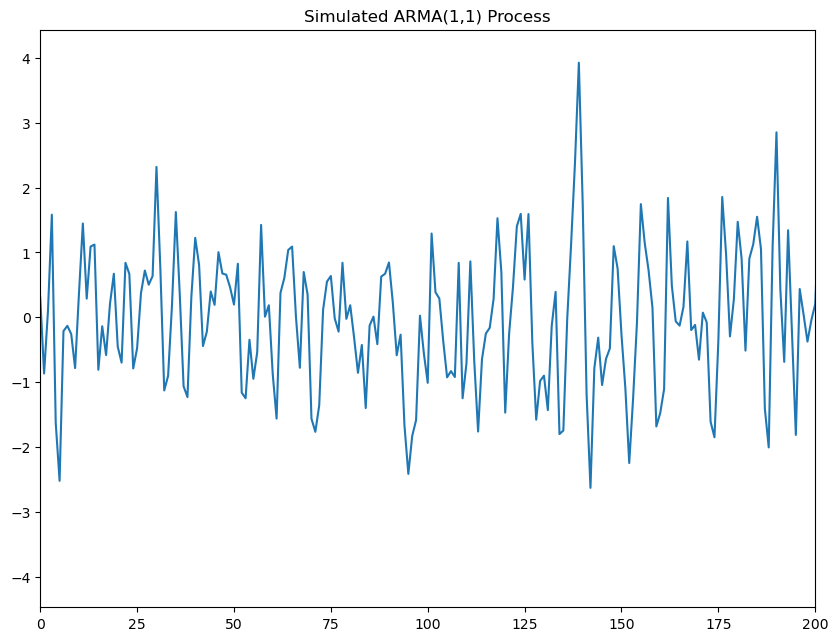

In [116]:
plt.plot(ARMA_11)
plt.title("Simulated ARMA(1,1) Process")
plt.xlim([0, 200])
plt.show()

In [5]:
# 2. Create matching datetime index (Daily frequency 'D')
time_index = pd.date_range(start="2026-09-01", periods=len(ARMA_11), freq="D")

# 3. Convert to a Pandas Time Series
time_series = pd.Series(ARMA_11, index=time_index)

print(time_series)

2026-09-01    0.304717
2026-09-02   -0.866295
2026-09-03    0.100343
2026-09-04    1.582858
2026-09-05   -1.626870
                ...   
2029-05-23    0.130468
2029-05-24    1.041217
2029-05-25    0.467717
2029-05-26    0.085478
2029-05-27    0.913233
Freq: D, Length: 1000, dtype: float64


In [6]:
time_series[0]

np.float64(0.30471707975443135)

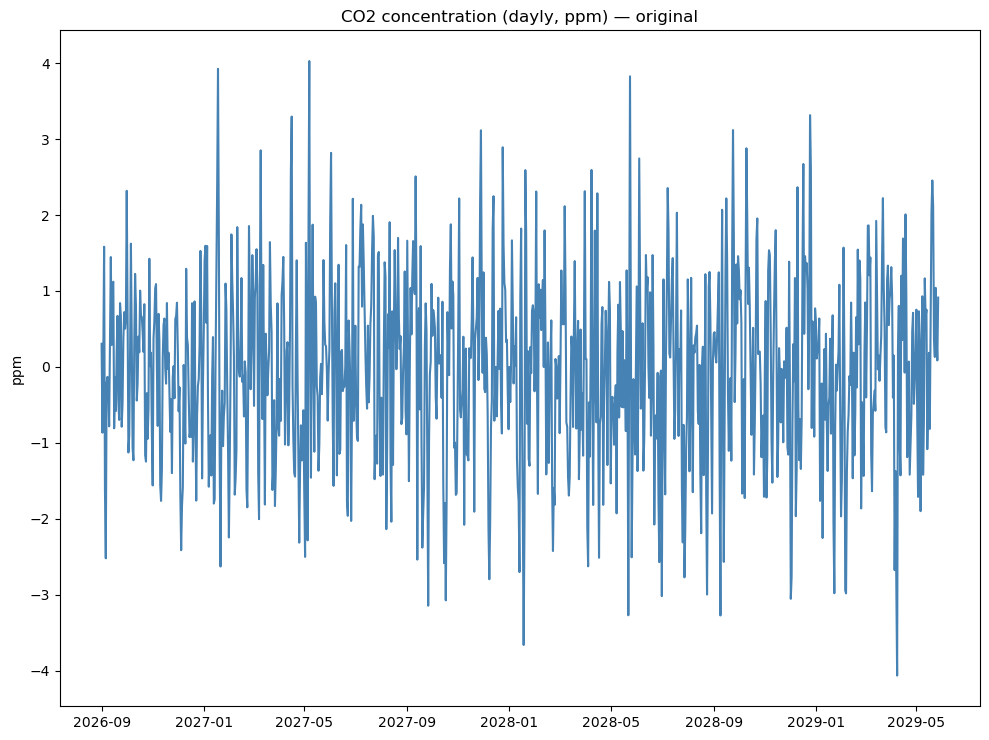

In [7]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(time_series, color="steelblue")
ax.set_title("CO2 concentration (dayly, ppm) — original")
ax.set_ylabel("ppm")
plt.tight_layout(); plt.show()


## ADFULLER TEST

Hypothesis Setup: Null Hypothesis (H₀): The series has a unit root (it is non-stationary).

Alternative Hypothesis (H₁): The series has no unit root (it is stationary).

[1] (https://www.statsmodels.org/devel/examples/notebooks/generated/stationarity_detrending_adf_kpss.html), 

[2] (https://www.geeksforgeeks.org/python/how-to-check-if-time-series-data-is-stationary-with-python/), 

[3] (https://www.youtube.com/watch?v=2cWsi6dfJ90)
     
The p-value Rule: If your p-value ≤ 0.05, you reject H₀ and conclude the series is stationary. 

If p > 0.05, your data is non-stationary

In [8]:
print("ADF on levels, p =", adfuller(time_series, autolag="AIC")[1])

ADF on levels, p = 8.644440719499159e-13


## PACF y ACF serie estacionaria 

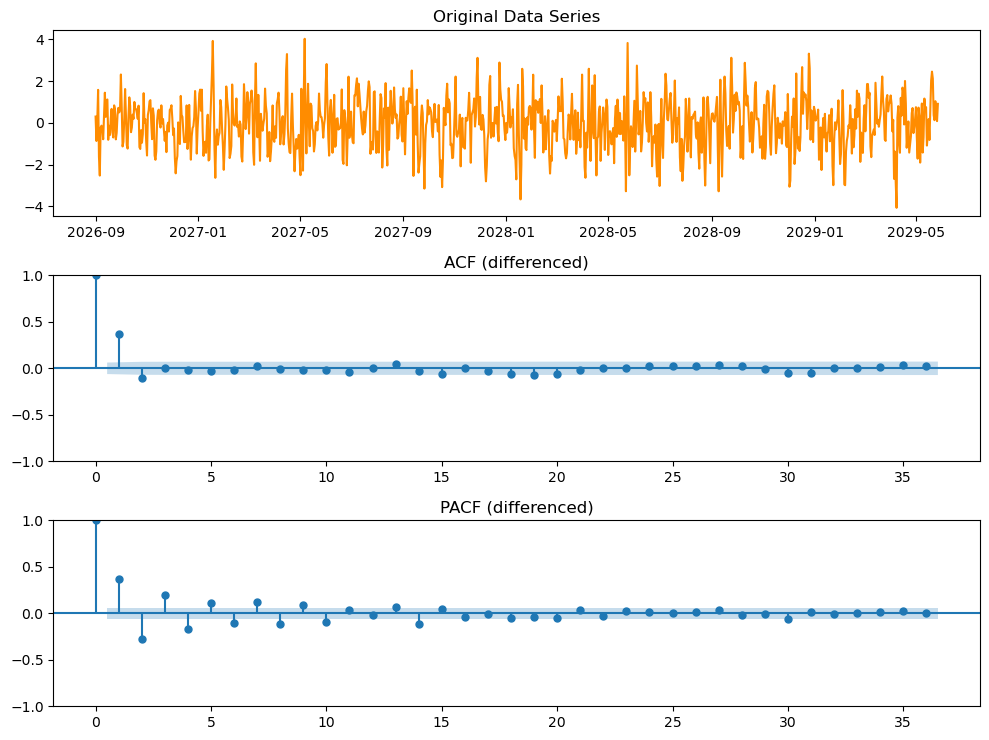

In [9]:
fig, axes = plt.subplots(3, 1)
axes[0].plot(time_series, color="darkorange")
axes[0].set_title("Original Data Series")
plot_acf(time_series,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(time_series, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

Como ambos (pacf y acf) tienen un comportamiento decreciente exponencial después del retardo 1, el orden de ARMA debería ser probado como p=q=1.

In [10]:
from statsmodels.tsa.arima.model import ARIMA
ARMA_model = ARIMA(time_series, order=(1,0,1), enforce_stationarity=False).fit()

print(ARMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1401.136
Date:                Mon, 14 Sep 2026   AIC                           2810.272
Time:                        17:46:11   BIC                           2829.895
Sample:                    09-01-2026   HQIC                          2817.731
                         - 05-27-2029                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0414      0.048     -0.864      0.388      -0.135       0.052
ar.L1         -0.2531      0.035     -7.255      0.000      -0.321      -0.185
ma.L1          0.9155      0.015     62.014      0.0

El modelo ajustado es : 
$$ y_t -\mu -  \phi_1 (y_{t-1}-\mu)=w_t+\theta_1w_{t-1}$$

Con $\phi_1 = -0.2531$ y $\theta_1=0.9155$. $Var(w_t)=0.9687$. $E[y_t]=-0.0414$

In [11]:
time_series.values.mean()

np.float64(-0.041604479501809025)

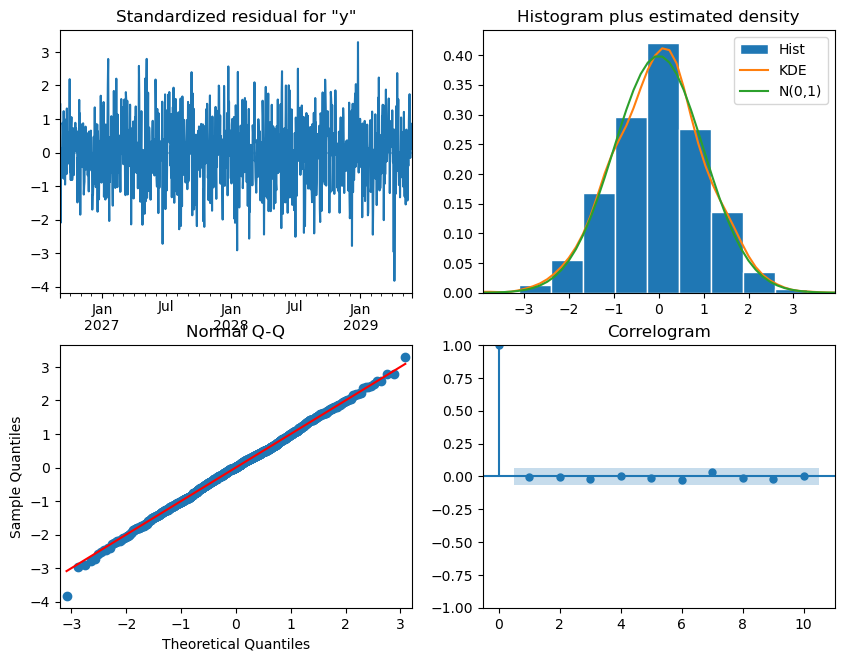

In [12]:
ARMA_model.plot_diagnostics()
plt.show()

In [13]:
time_series

2026-09-01    0.304717
2026-09-02   -0.866295
2026-09-03    0.100343
2026-09-04    1.582858
2026-09-05   -1.626870
                ...   
2029-05-23    0.130468
2029-05-24    1.041217
2029-05-25    0.467717
2029-05-26    0.085478
2029-05-27    0.913233
Freq: D, Length: 1000, dtype: float64

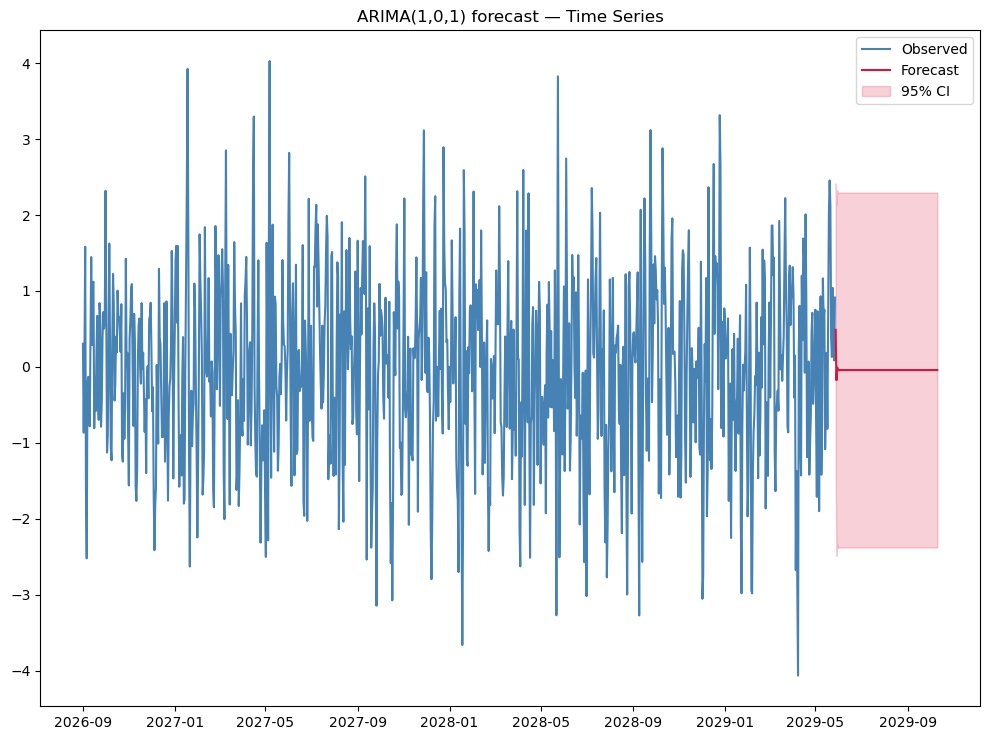

In [14]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 136
fc   = ARMA_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(time_series.index[-1], periods=steps + 1, freq="D")[1:]

fig, ax = plt.subplots()
ax.plot(time_series, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(1,0,1) forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

### Ejemplo Rio Nilo

In [15]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline
nile = sm.datasets.nile.load_pandas().data

In [16]:
type(nile)

pandas.core.frame.DataFrame

In [17]:
nile

,year,volume
0,1871.0,1120.0
1,1872.0,1160.0
2,1873.0,963.0
3,1874.0,1210.0
4,1875.0,1160.0
...,...,...
95,1966.0,746.0
96,1967.0,919.0
97,1968.0,718.0
98,1969.0,714.0


In [18]:
nile = sm.datasets.nile.load_pandas().data["volume"].astype(float)
nile.index = pd.date_range("1871-01-01", periods=len(nile), freq="YS")

In [19]:
nile

1871-01-01    1120.0
1872-01-01    1160.0
1873-01-01     963.0
1874-01-01    1210.0
1875-01-01    1160.0
               ...  
1966-01-01     746.0
1967-01-01     919.0
1968-01-01     718.0
1969-01-01     714.0
1970-01-01     740.0
Freq: YS-JAN, Name: volume, Length: 100, dtype: float64

In [20]:
type(nile)

pandas.core.series.Series

In [21]:
nile.index

DatetimeIndex(['1871-01-01', '1872-01-01', '1873-01-01', '1874-01-01',
               '1875-01-01', '1876-01-01', '1877-01-01', '1878-01-01',
               '1879-01-01', '1880-01-01', '1881-01-01', '1882-01-01',
               '1883-01-01', '1884-01-01', '1885-01-01', '1886-01-01',
               '1887-01-01', '1888-01-01', '1889-01-01', '1890-01-01',
               '1891-01-01', '1892-01-01', '1893-01-01', '1894-01-01',
               '1895-01-01', '1896-01-01', '1897-01-01', '1898-01-01',
               '1899-01-01', '1900-01-01', '1901-01-01', '1902-01-01',
               '1903-01-01', '1904-01-01', '1905-01-01', '1906-01-01',
               '1907-01-01', '1908-01-01', '1909-01-01', '1910-01-01',
               '1911-01-01', '1912-01-01', '1913-01-01', '1914-01-01',
               '1915-01-01', '1916-01-01', '1917-01-01', '1918-01-01',
               '1919-01-01', '1920-01-01', '1921-01-01', '1922-01-01',
               '1923-01-01', '1924-01-01', '1925-01-01', '1926-01-01',
      

In [22]:
nile.values

array([1120., 1160.,  963., 1210., 1160., 1160.,  813., 1230., 1370.,
       1140.,  995.,  935., 1110.,  994., 1020.,  960., 1180.,  799.,
        958., 1140., 1100., 1210., 1150., 1250., 1260., 1220., 1030.,
       1100.,  774.,  840.,  874.,  694.,  940.,  833.,  701.,  916.,
        692., 1020., 1050.,  969.,  831.,  726.,  456.,  824.,  702.,
       1120., 1100.,  832.,  764.,  821.,  768.,  845.,  864.,  862.,
        698.,  845.,  744.,  796., 1040.,  759.,  781.,  865.,  845.,
        944.,  984.,  897.,  822., 1010.,  771.,  676.,  649.,  846.,
        812.,  742.,  801., 1040.,  860.,  874.,  848.,  890.,  744.,
        749.,  838., 1050.,  918.,  986.,  797.,  923.,  975.,  815.,
       1020.,  906.,  901., 1170.,  912.,  746.,  919.,  718.,  714.,
        740.])

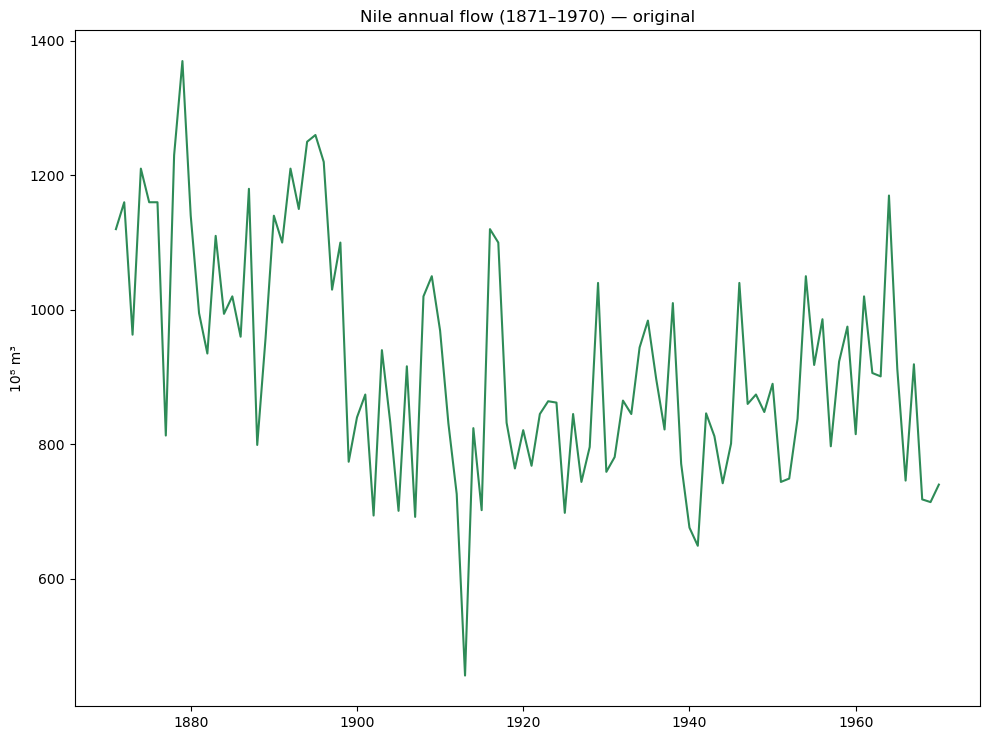

In [23]:
# ---------------------------------------------------------------
# 2. Original
# ---------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(nile, color="seagreen")
ax.set_title("Nile annual flow (1871–1970) — original")
ax.set_ylabel("10⁸ m³")
plt.tight_layout(); plt.show()

## Prueba de estacionaridad

In [24]:
print("ADF on levels, p =", adfuller(nile, autolag="AIC")[1])

ADF on levels, p = 0.001175887950387114


La señal es estacionaria

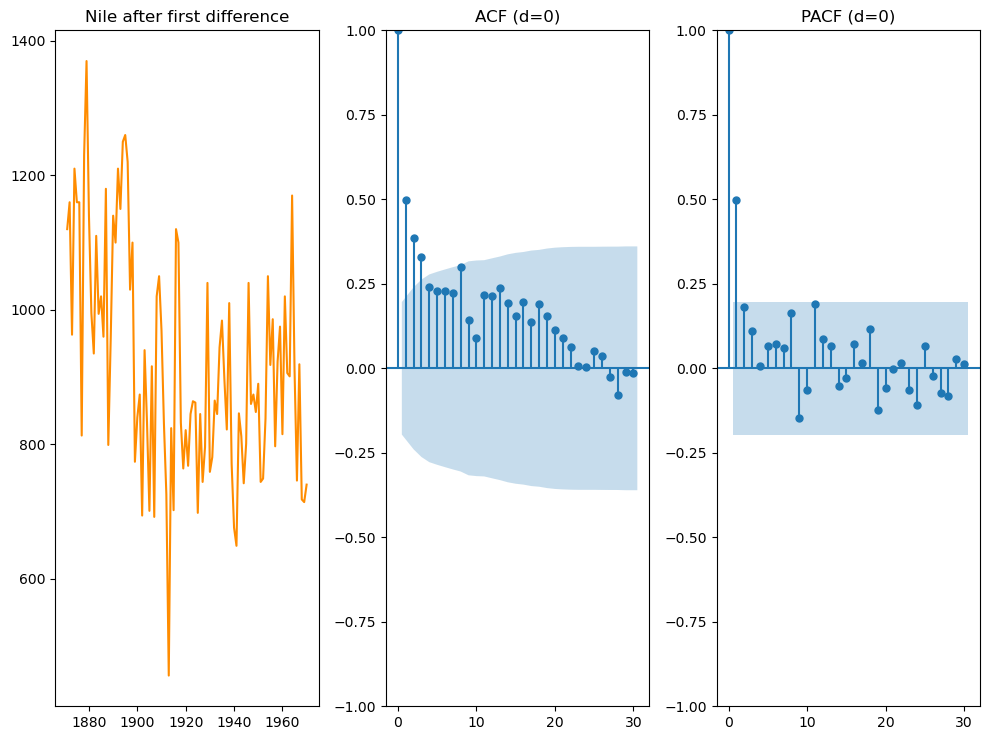

In [25]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(nile, color="darkorange")
axes[0].set_title("Nile after first difference")
plot_acf(nile,  ax=axes[1], lags=30, title="ACF (d=0)")
plot_pacf(nile, ax=axes[2], lags=30, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

Probar ARMA(1,0,1)

In [26]:
from statsmodels.tsa.arima.model import ARIMA
ARMA_model = ARIMA(nile, order=(1,0,1), enforce_stationarity=False).fit()

print(ARMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 volume   No. Observations:                  100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -623.849
Date:                Mon, 14 Sep 2026   AIC                           1255.697
Time:                        17:46:59   BIC                           1266.037
Sample:                    01-01-1871   HQIC                          1259.879
                         - 01-01-1970                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        891.2845     51.941     17.159      0.000     789.481     993.088
ar.L1          0.8641      0.077     11.202      0.000       0.713       1.015
ma.L1         -0.5617      0.143     -3.919      0.0

El modelo ajustado es : 
$$ y_t -\mu -  \phi_1 (y_{t-1}-\mu)=w_t+\theta_1w_{t-1}$$

Con $\phi_1 = 0.8641$ y $\theta_1=-0.5617$. $Var(w_t)=19730$. $E[y_t]=891.2845$

In [27]:
nile.values.mean()

np.float64(919.35)

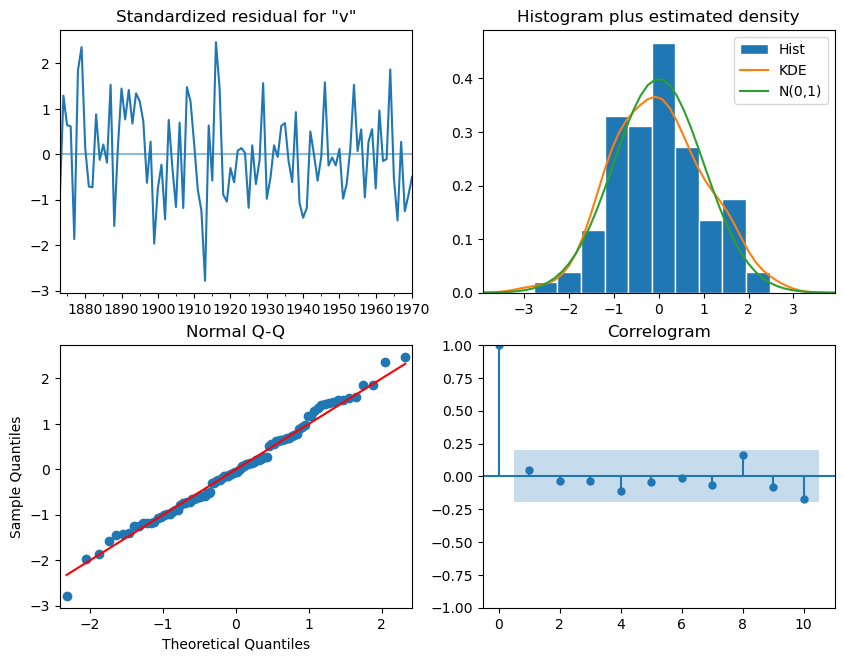

In [28]:
ARMA_model.plot_diagnostics()
plt.show()

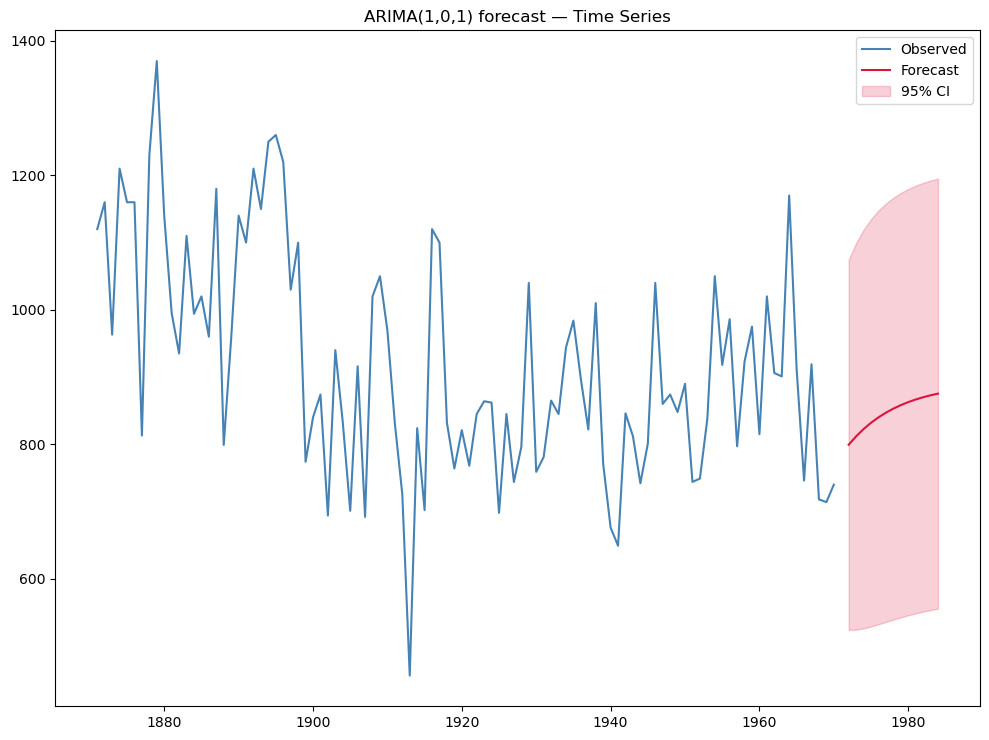

In [29]:
# 5. Forecast 13 periods 
# ---------------------------------------------------------------
steps = 13
fc   = ARMA_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(nile.index[-1], periods=steps + 1, freq="Y")[1:]

fig, ax = plt.subplots()
ax.plot(nile, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(1,0,1) forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

### Ejemplo CO2

In [30]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline
co2 = sm.datasets.co2.load_pandas().data

In [31]:
type(co2)

pandas.core.frame.DataFrame

In [32]:
co2

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4
...,...
2001-12-01,370.3
2001-12-08,370.8
2001-12-15,371.2
2001-12-22,371.3


In [33]:
co2.index

DatetimeIndex(['1958-03-29', '1958-04-05', '1958-04-12', '1958-04-19',
               '1958-04-26', '1958-05-03', '1958-05-10', '1958-05-17',
               '1958-05-24', '1958-05-31',
               ...
               '2001-10-27', '2001-11-03', '2001-11-10', '2001-11-17',
               '2001-11-24', '2001-12-01', '2001-12-08', '2001-12-15',
               '2001-12-22', '2001-12-29'],
              dtype='datetime64[ns]', length=2284, freq='W-SAT')

Los datos viene grabados por dia desde marzo 29 de 1958 hasta diciembre 29 de 2001. Se reacomodan por mes sacando promedios

In [34]:
co2 = sm.datasets.co2.load_pandas().data['co2']
co2 = co2.resample('MS').mean().interpolate().loc['1980':]

In [35]:
co2

1980-01-01    337.925
1980-02-01    338.225
1980-03-01    340.060
1980-04-01    340.750
1980-05-01    341.340
               ...   
2001-08-01    369.425
2001-09-01    367.880
2001-10-01    368.050
2001-11-01    369.375
2001-12-01    371.020
Freq: MS, Name: co2, Length: 264, dtype: float64

In [36]:
co2.values

array([337.925, 338.225, 340.06 , 340.75 , 341.34 , 340.95 , 339.375,
       337.6  , 335.875, 336.025, 337.06 , 338.2  , 339.22 , 340.45 ,
       341.4  , 342.45 , 342.82 , 342.125, 340.425, 338.4  , 336.7  ,
       336.94 , 338.425, 339.6  , 340.7  , 341.55 , 342.675, 343.475,
       343.96 , 343.3  , 341.92 , 339.625, 338.025, 337.9  , 339.275,
       340.425, 341.34 , 342.5  , 343.15 , 344.9  , 345.65 , 345.275,
       343.82 , 342.15 , 339.875, 340.02 , 341.15 , 342.98 , 343.675,
       344.425, 345.175, 347.4  , 347.35 , 346.66 , 345.2  , 343.3  ,
       341.12 , 341.475, 342.85 , 344.14 , 344.925, 345.875, 347.44 ,
       348.325, 348.825, 348.18 , 346.45 , 344.3  , 343.   , 342.8  ,
       344.22 , 345.575, 346.25 , 346.825, 347.74 , 349.525, 350.08 ,
       349.375, 347.825, 345.82 , 344.8  , 344.1  , 345.62 , 346.875,
       348.   , 348.5  , 349.475, 350.85 , 351.74 , 351.15 , 349.45 ,
       348.08 , 346.4  , 346.44 , 347.925, 348.925, 350.4  , 351.775,
       352.125, 353.

In [37]:
co2.index

DatetimeIndex(['1980-01-01', '1980-02-01', '1980-03-01', '1980-04-01',
               '1980-05-01', '1980-06-01', '1980-07-01', '1980-08-01',
               '1980-09-01', '1980-10-01',
               ...
               '2001-03-01', '2001-04-01', '2001-05-01', '2001-06-01',
               '2001-07-01', '2001-08-01', '2001-09-01', '2001-10-01',
               '2001-11-01', '2001-12-01'],
              dtype='datetime64[ns]', length=264, freq='MS')

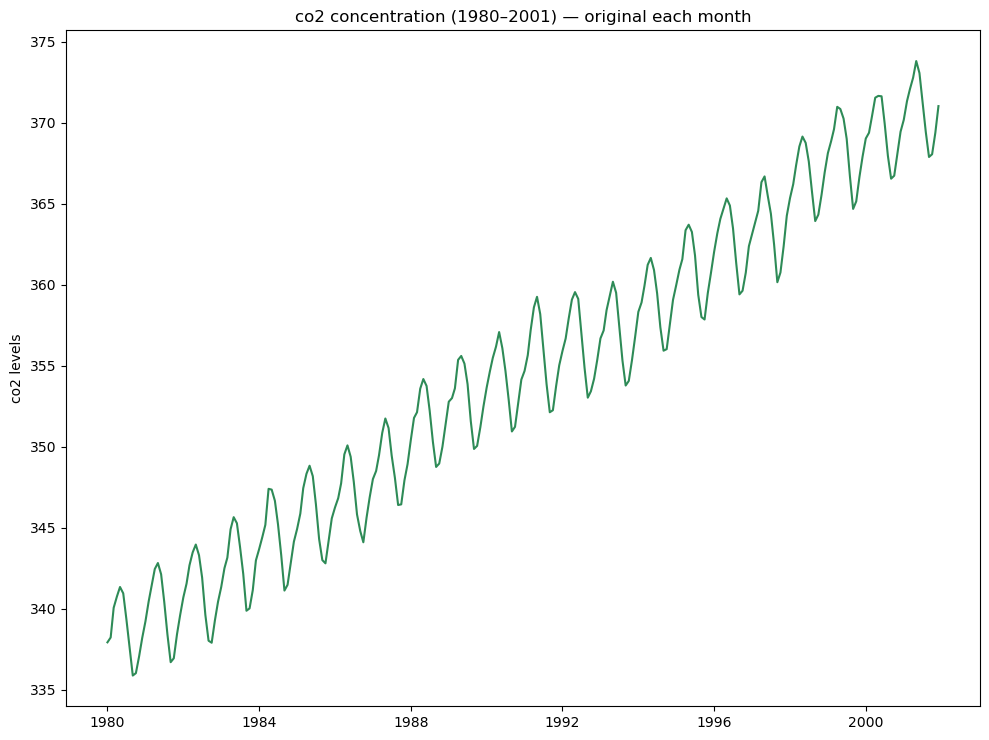

In [38]:
# ---------------------------------------------------------------
# 2. Original
# ---------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(co2, color="seagreen")
ax.set_title("co2 concentration (1980–2001) — original each month")
ax.set_ylabel("co2 levels")
plt.tight_layout(); plt.show()

Esto no es estacionario: ensayamos una primera diferencia de orden 12:

$$ z_t = y_t-y_{t-12} $$

In [39]:
co2_diff = co2.diff(12).dropna()

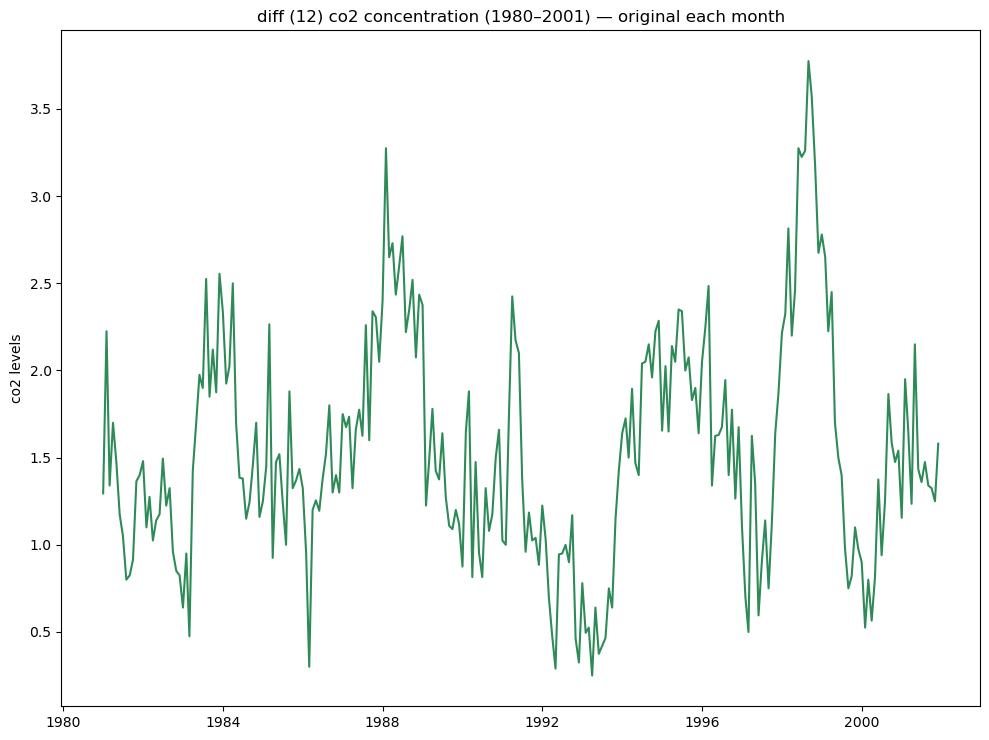

In [40]:
# ---------------------------------------------------------------
# 2. diff(12)
# ---------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(co2_diff, color="seagreen")
ax.set_title("diff (12) co2 concentration (1980–2001) — original each month")
ax.set_ylabel("co2 levels")
plt.tight_layout(); plt.show()

# Prueba de Estacionaridad

In [41]:
print("ADF on levels, p =", adfuller(co2_diff, autolag="AIC")[1])

ADF on levels, p = 0.016620035777423985


Como pvalor es menor o igual o 0.05, se puede considerar que la diff(12) es estacionaria

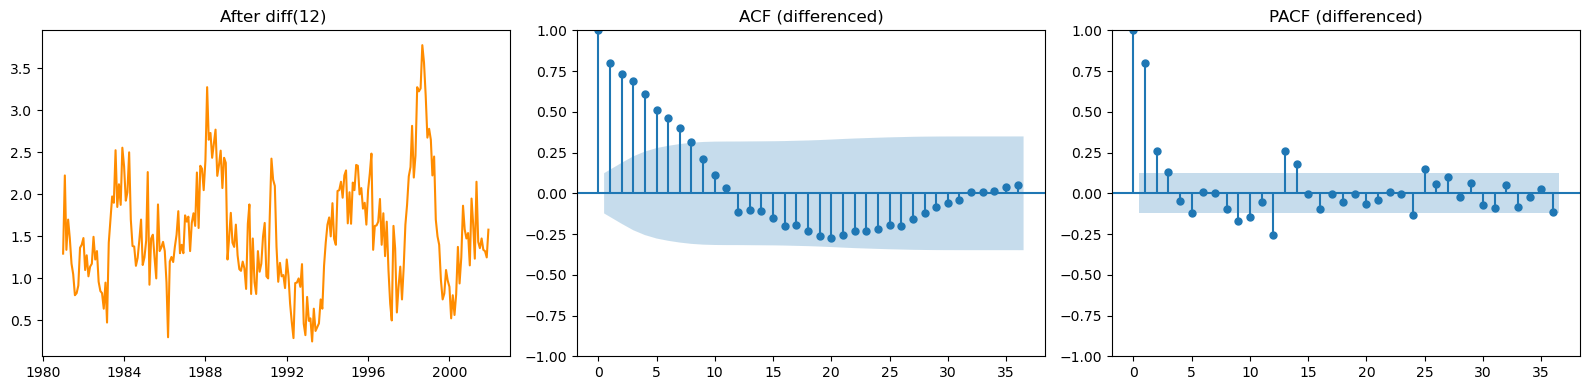

In [42]:
# ---------------------------------------------------------------
# 3. Difference: one seasonal (12)  → stationary
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(co2_diff, color="darkorange")
axes[0].set_title("After diff(12) ")
plot_acf(co2_diff,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(co2_diff, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

Como en periodos 12, 24, 36 PACF se amortigua y ACF es 0, entonces puede ser P =1 Q=0 o 1 , D=1 (por la differecial en 12) , S=12
Como en los periodos 1,2,3,4,5 Ambos amortiguan puede ser p=q=1 d=0, 
Tambien puede haber una compenente adicional de periodo 1 por los picos en 13 y 14 (12+1) (12+2)

Ensayemos ARIMA(1,0,1)(1,1,1)



In [43]:
SARIMA_Model = ARIMA(co2, order=(1, 0, 1),
                seasonal_order=(1, 1, 1, 12)).fit()
print(SARIMA_Model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                              co2   No. Observations:                  264
Model:             ARIMA(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                 -57.077
Date:                          Mon, 14 Sep 2026   AIC                            124.154
Time:                                  17:48:23   BIC                            141.801
Sample:                              01-01-1980   HQIC                           131.255
                                   - 12-01-2001                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.000   7742.064      0.000       1.000       1.000
ma.L1         -0.3827      0.054     -7.026      0.

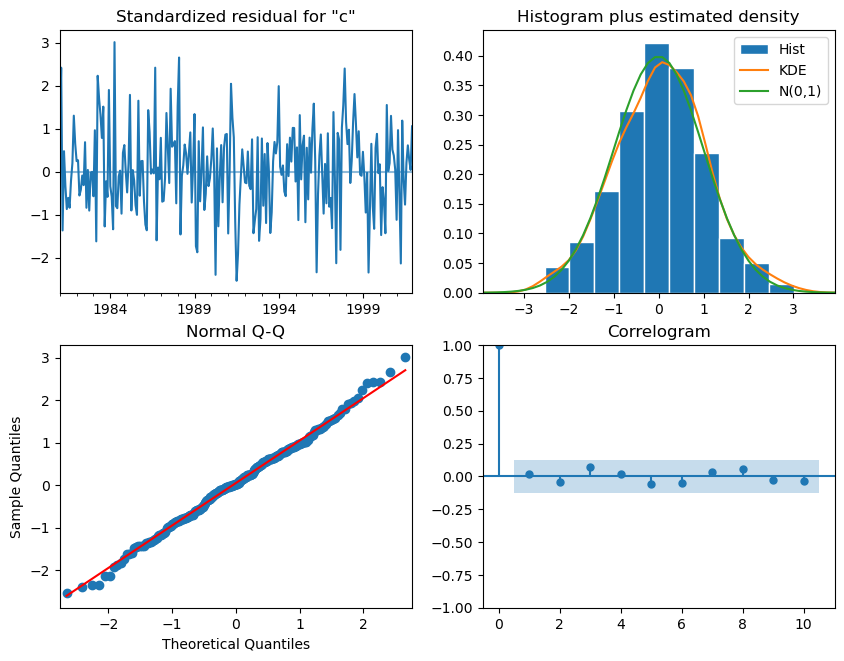

In [44]:
SARIMA_Model.plot_diagnostics()
plt.show()

In [45]:
np.random.seed(42)
residuals = np.random.normal(0, 1, 100)

# Run the Ljung-Box test for up to 10 lags
results = sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)
print(results)

     lb_stat  lb_pvalue
10  7.468256   0.680622


In [46]:
from statsmodels.stats.diagnostic import acorr_ljungbox
sm.stats.acorr_ljungbox(SARIMA_Model.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,944.898368,1.376640e-196


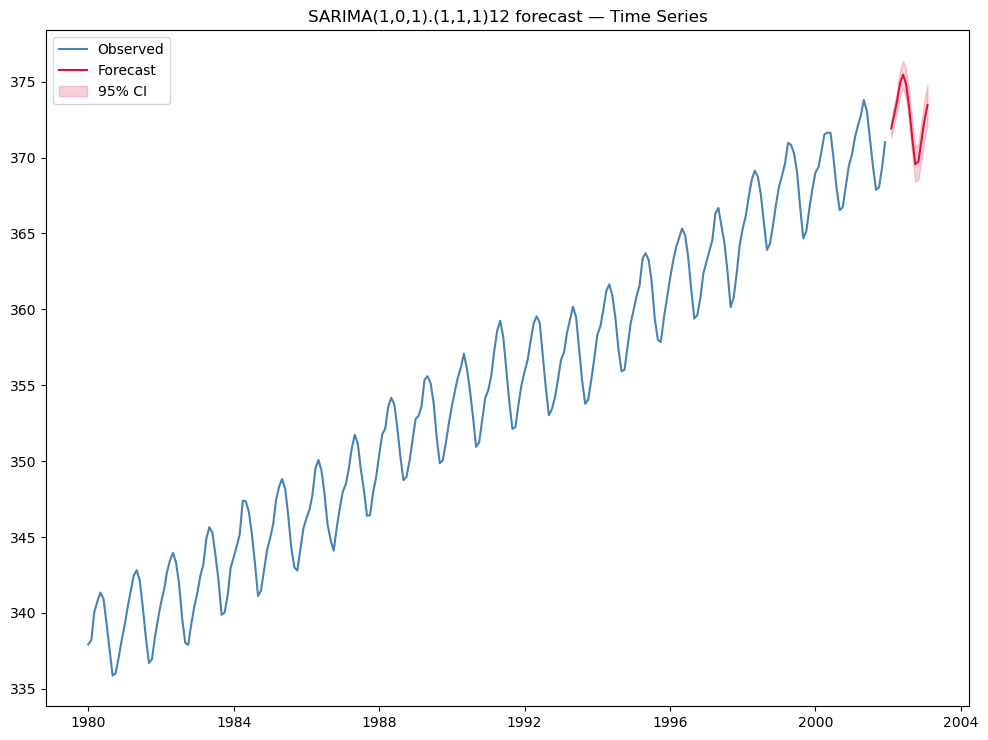

In [47]:
# 5. Forecast 13 periods 
# ---------------------------------------------------------------
steps = 13
fc   = SARIMA_Model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(co2.index[-1], periods=steps + 1, freq="M")[1:]

fig, ax = plt.subplots()
ax.plot(co2, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("SARIMA(1,0,1).(1,1,1)12 forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

Los residuos parecen correlacionados

## Probemos otro modelo

Una diferencia de 1 de la diff(12)

$$L_t= x_t-x_{t-12} $$
$$z_t=L_t-L_{t-1}$$

In [48]:
co2_diff = co2.diff(12).diff().dropna() 

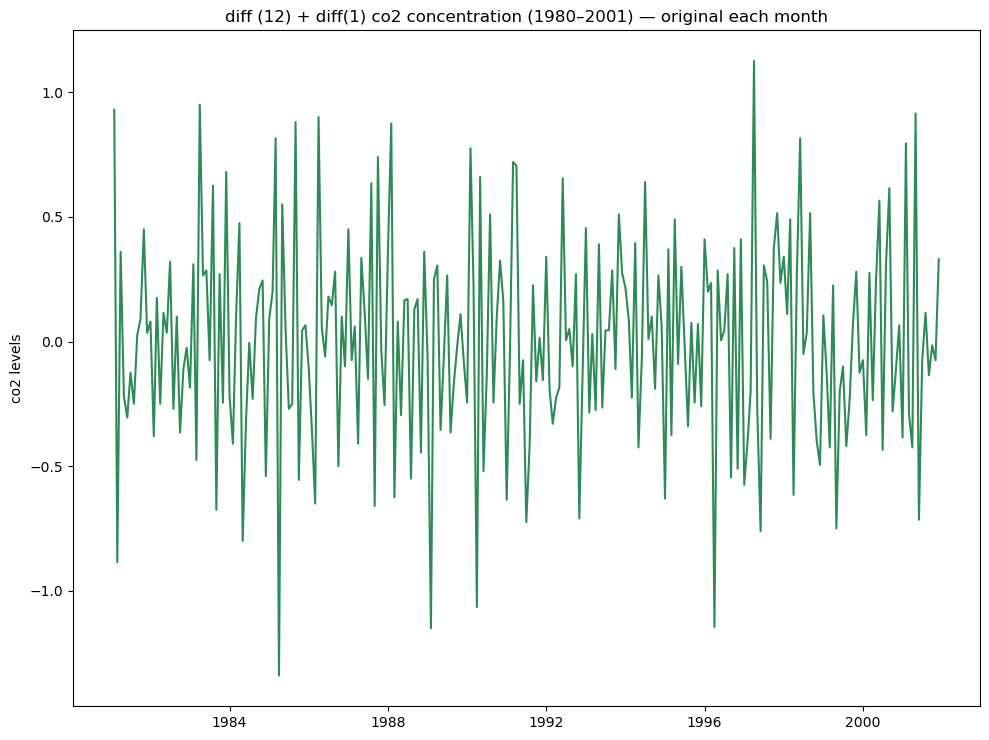

In [49]:
# ---------------------------------------------------------------
# 2. co2.diff(12).diff()
# ---------------------------------------------------------------
fig, ax = plt.subplots()
ax.plot(co2_diff, color="seagreen")
ax.set_title("diff (12) + diff(1) co2 concentration (1980–2001) — original each month")
ax.set_ylabel("co2 levels")
plt.tight_layout(); plt.show()

#### Prueba de Estacionaridad

In [50]:
print("ADF on levels, p =", adfuller(co2_diff, autolag="AIC")[1])

ADF on levels, p = 3.9212272127371674e-08


Queda muy estacionaria

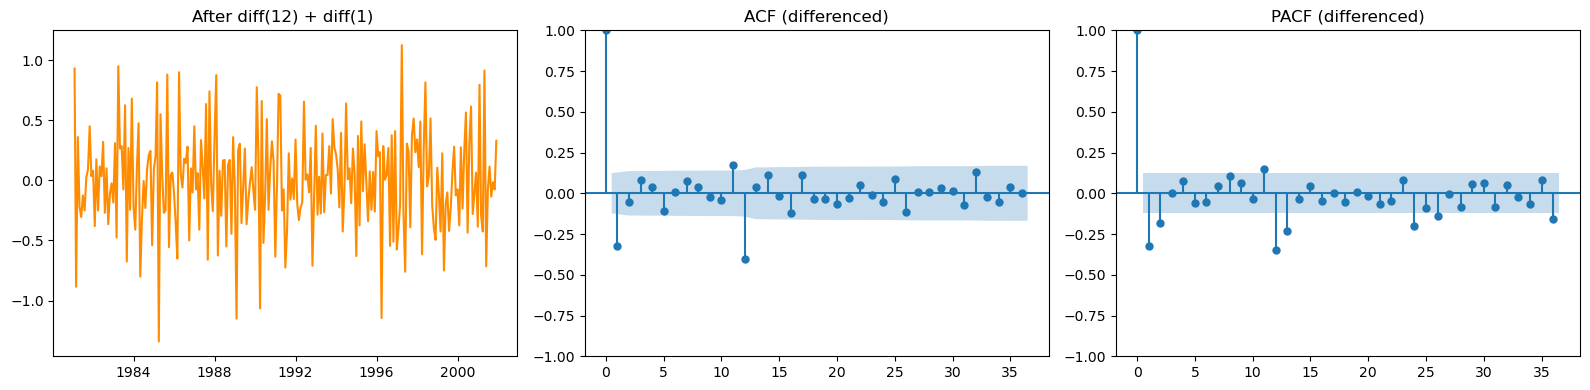

In [51]:
# ---------------------------------------------------------------
# 3. Difference: one seasonal (12) + diff(1)  → stationary
# ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(co2_diff, color="darkorange")
axes[0].set_title("After diff(12) + diff(1) ")
plot_acf(co2_diff,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(co2_diff, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

Ensayamos p=q=1, d=1, D=1, P=Q=1

In [52]:
SARIMA_Model = ARIMA(co2, order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12)).fit()
print(SARIMA_Model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                              co2   No. Observations:                  264
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -55.121
Date:                          Mon, 14 Sep 2026   AIC                            120.241
Time:                                  17:49:03   BIC                            137.869
Sample:                              01-01-1980   HQIC                           127.335
                                   - 12-01-2001                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0298      0.184      0.162      0.871      -0.330       0.390
ma.L1         -0.4039      0.171     -2.358      0.

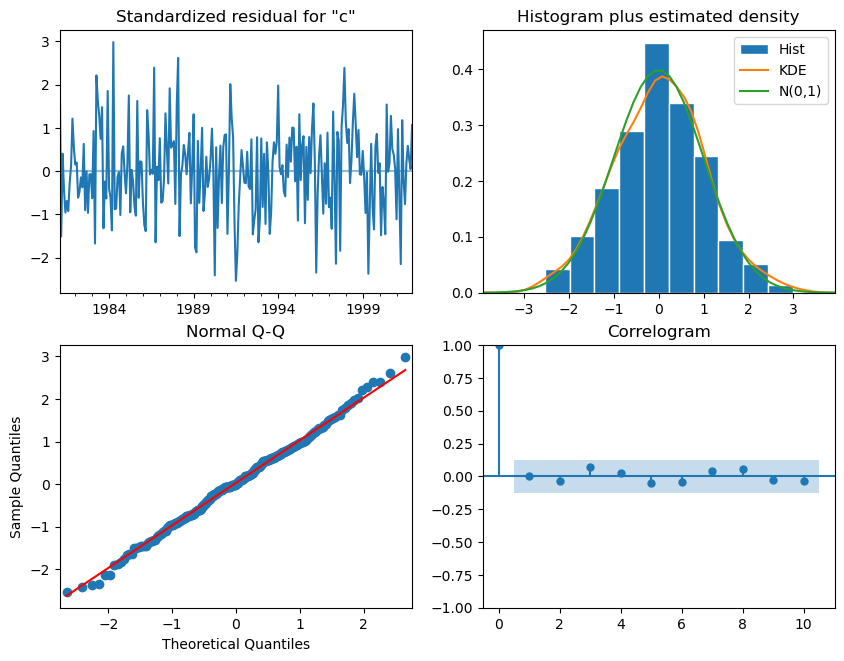

In [53]:
SARIMA_Model.plot_diagnostics()
plt.show()

In [54]:
from statsmodels.stats.diagnostic import acorr_ljungbox
sm.stats.acorr_ljungbox(SARIMA_Model.resid, lags=[11], return_df=True)

,lb_stat,lb_pvalue
11,0.022023,1.0


Null Hypothesis ($H_0$): The residuals are independently distributed (no autocorrelation; they are white noise).

Alternative Hypothesis ($H_a$): The residuals exhibit serial correlation (patterns remain, meaning the model can be improved). 

[1] (https://en.wikipedia.org/wiki/Ljung%E2%80%93Box_test), 

[2] (https://www.statology.org/ljung-box-test-python/)

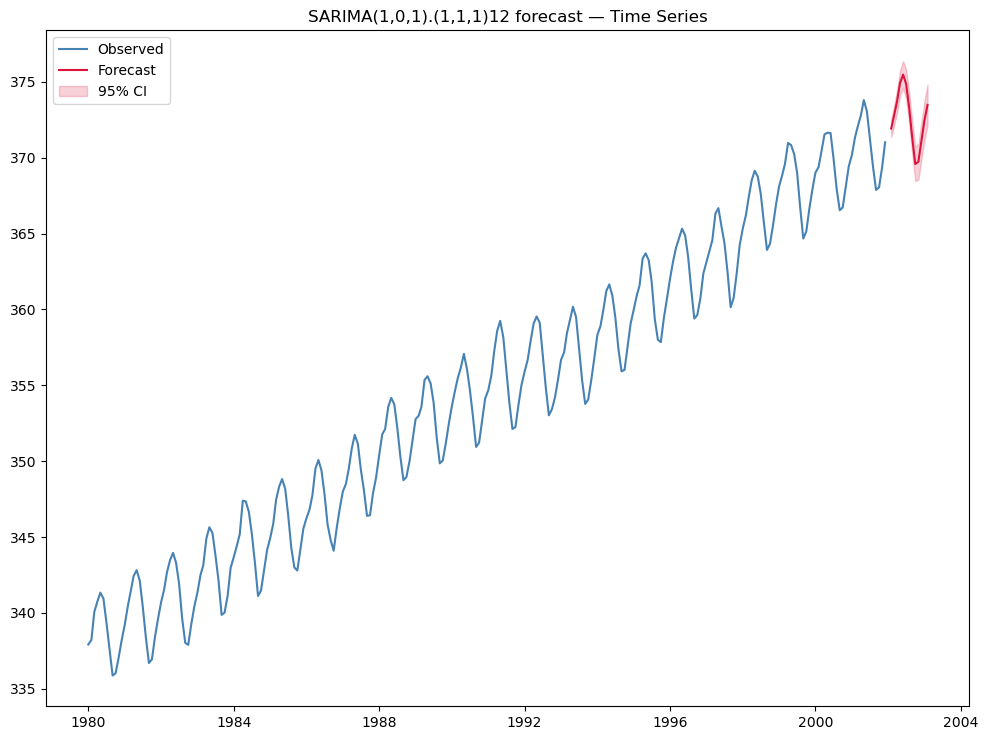

In [55]:
# 5. Forecast 13 periods 
# ---------------------------------------------------------------
steps = 13
fc   = SARIMA_Model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(co2.index[-1], periods=steps + 1, freq="M")[1:]

fig, ax = plt.subplots()
ax.plot(co2, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("SARIMA(1,0,1).(1,1,1)12 forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

In [56]:
SARIMA_Model = ARIMA(co2, order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12)).fit()
print(SARIMA_Model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                              co2   No. Observations:                  264
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -55.121
Date:                          Mon, 14 Sep 2026   AIC                            120.241
Time:                                  17:49:21   BIC                            137.869
Sample:                              01-01-1980   HQIC                           127.335
                                   - 12-01-2001                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0298      0.184      0.162      0.871      -0.330       0.390
ma.L1         -0.4039      0.171     -2.358      0.

El modelo es:
$$ (1-0.0761B^{12})(1-0.0298B)(1-B)(1-B^{12})x_t=(1-0.9951B^{12})(1-0.4039B)w_t$$
$$ Var[w_t]=0.0792$$

      lb_stat  lb_pvalue
1    0.000220   0.988175
2    0.005881   0.997064
3    0.006968   0.999846
4    0.012046   0.999982
5    0.013471   0.999999
6    0.013669   1.000000
7    0.015499   1.000000
8    0.019667   1.000000
9    0.019682   1.000000
10   0.019743   1.000000
11   0.022023   1.000000
12  44.182730   0.000014
13  44.183938   0.000029
14  44.184334   0.000055
15  44.184400   0.000103
24  44.185455   0.007260
18  44.184885   0.000543
34  44.187281   0.113328
36  44.187597   0.164174


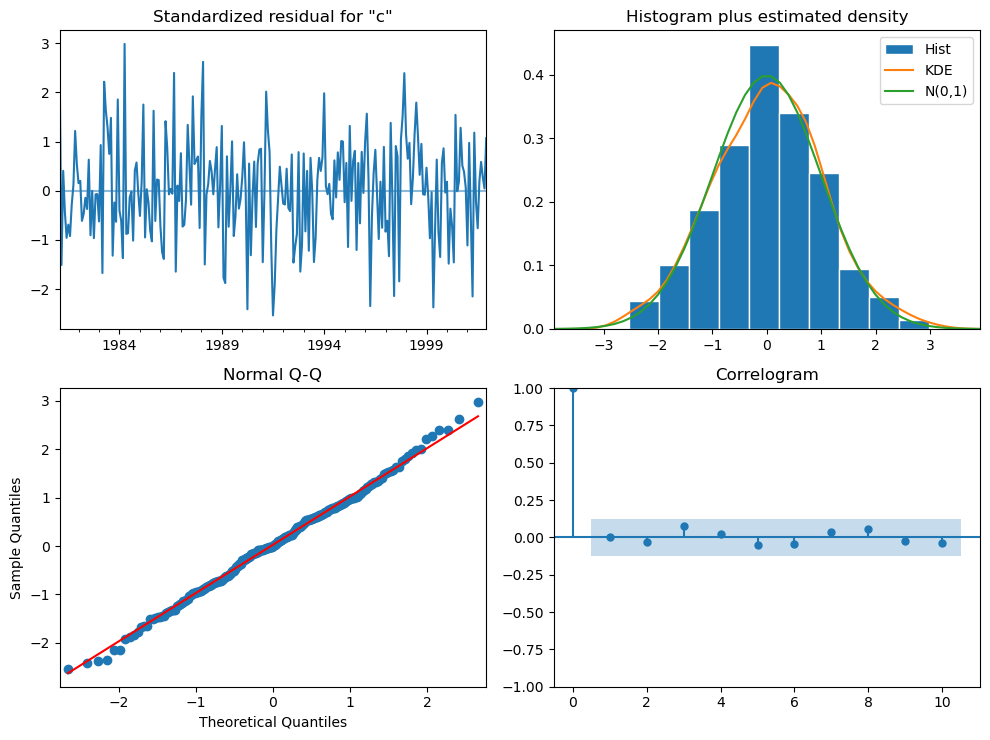

In [57]:
print(acorr_ljungbox(SARIMA_Model.resid, lags=[1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,24,18,34,36], return_df=True))
SARIMA_Model.plot_diagnostics(); plt.tight_layout(); plt.show()

In [58]:
pip install pmdarima

In [59]:
co2 = sm.datasets.co2.load_pandas().data['co2']
co2 = co2.resample('MS').mean().interpolate().loc['1980':]

In [60]:
import numpy as np
from scipy import stats

# 1. Prepare your data (Must be strictly positive, > 0)
data = co2

# 2. Apply Box-Cox transformation
# transformed_data: The normalized data
# best_lambda: The automatically chosen optimal lambda value
transformed_data, best_lambda = stats.boxcox(data)

print(f"Optimal Lambda: {best_lambda}")
print(f"Transformed Data: {transformed_data}")

Optimal Lambda: 0.06472191068973673
Transformed Data: [7.07189375 7.07318732 7.08107639 7.08403256 7.08655586 7.08488837
 7.07813609 7.07049117 7.06302548 7.06367609 7.06815793 7.07307956
 7.07747    7.08274796 7.08681224 7.09129205 7.09286759 7.08990682
 7.08264086 7.07394141 7.06660049 7.06763895 7.07404911 7.0791025
 7.08381853 7.087453   7.09225034 7.09565282 7.09771197 7.09490916
 7.08903242 7.07920984 7.07232506 7.0717859  7.07770639 7.08264086
 7.08655586 7.09150505 7.09427146 7.10169518 7.104866   7.1032814
 7.09711786 7.09001342 7.08028285 7.08090485 7.08574372 7.09354841
 7.09650229 7.09968366 7.10285856 7.11223962 7.11202943 7.10912588
 7.10296428 7.09490916 7.08561545 7.08713265 7.09299526 7.0984755
 7.10180098 7.10581599 7.11240775 7.11612308 7.11821824 7.11551496
 7.10824112 7.09915388 7.09363349 7.09278246 7.09881473 7.10454921
 7.10739802 7.1098207  7.11366818 7.12114674 7.12346473 7.12051966
 7.11402511 7.10558382 7.10127192 7.09830586 7.10473929 7.11003119
 7.11475972

In [61]:
transformed_data

array([7.07189375, 7.07318732, 7.08107639, 7.08403256, 7.08655586,
       7.08488837, 7.07813609, 7.07049117, 7.06302548, 7.06367609,
       7.06815793, 7.07307956, 7.07747   , 7.08274796, 7.08681224,
       7.09129205, 7.09286759, 7.08990682, 7.08264086, 7.07394141,
       7.06660049, 7.06763895, 7.07404911, 7.0791025 , 7.08381853,
       7.087453  , 7.09225034, 7.09565282, 7.09771197, 7.09490916,
       7.08903242, 7.07920984, 7.07232506, 7.0717859 , 7.07770639,
       7.08264086, 7.08655586, 7.09150505, 7.09427146, 7.10169518,
       7.104866  , 7.1032814 , 7.09711786, 7.09001342, 7.08028285,
       7.08090485, 7.08574372, 7.09354841, 7.09650229, 7.09968366,
       7.10285856, 7.11223962, 7.11202943, 7.10912588, 7.10296428,
       7.09490916, 7.08561545, 7.08713265, 7.09299526, 7.0984755 ,
       7.10180098, 7.10581599, 7.11240775, 7.11612308, 7.11821824,
       7.11551496, 7.10824112, 7.09915388, 7.09363349, 7.09278246,
       7.09881473, 7.10454921, 7.10739802, 7.1098207 , 7.11366

In [62]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    transformed_data,
    seasonal=True, m=12,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='aic', # Or 'bic',
    start_p=0, start_q=0,
    max_p=2, max_q=2, d=1, D=0, max_P=2, max_Q=2
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-2654.886, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-2018.388, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-2314.153, Time=0.60 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-2017.751, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=-2239.917, Time=0.35 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=-2654.781, Time=0.65 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=-2631.632, Time=1.09 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=-2342.502, Time=0.98 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.77 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=-2620.080, Time=0.97 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=-2514.286, Time=0.36 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-2093.772, Time=0.26 sec
 ARIMA(1,1,1)(1,0,1)[12

In [63]:
best_model = ARIMA(transformed_data, order=(1, 1, 1),
                seasonal_order=(1, 0, 1, 12)).fit()
print(best_model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  264
Model:             ARIMA(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                1342.242
Date:                          Mon, 14 Sep 2026   AIC                          -2674.484
Time:                                  17:51:26   BIC                          -2656.623
Sample:                                       0   HQIC                         -2667.306
                                          - 264                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2268      0.234      0.970      0.332      -0.232       0.685
ma.L1         -0.4861      0.212     -2.293      0.

     lb_stat  lb_pvalue
1   0.000007   0.997816
2   0.000348   0.999826
3   0.000470   0.999997
4   0.000552   1.000000
5   0.000554   1.000000
6   0.000828   1.000000
7   0.001376   1.000000
8   0.002053   1.000000
9   0.002125   1.000000
10  0.002148   1.000000
11  0.002263   1.000000
12  0.002476   1.000000
13  0.002531   1.000000
14  0.002599   1.000000
15  0.002599   1.000000
24  0.002958   1.000000
18  0.002746   1.000000
34  0.003710   1.000000
36  0.003898   1.000000


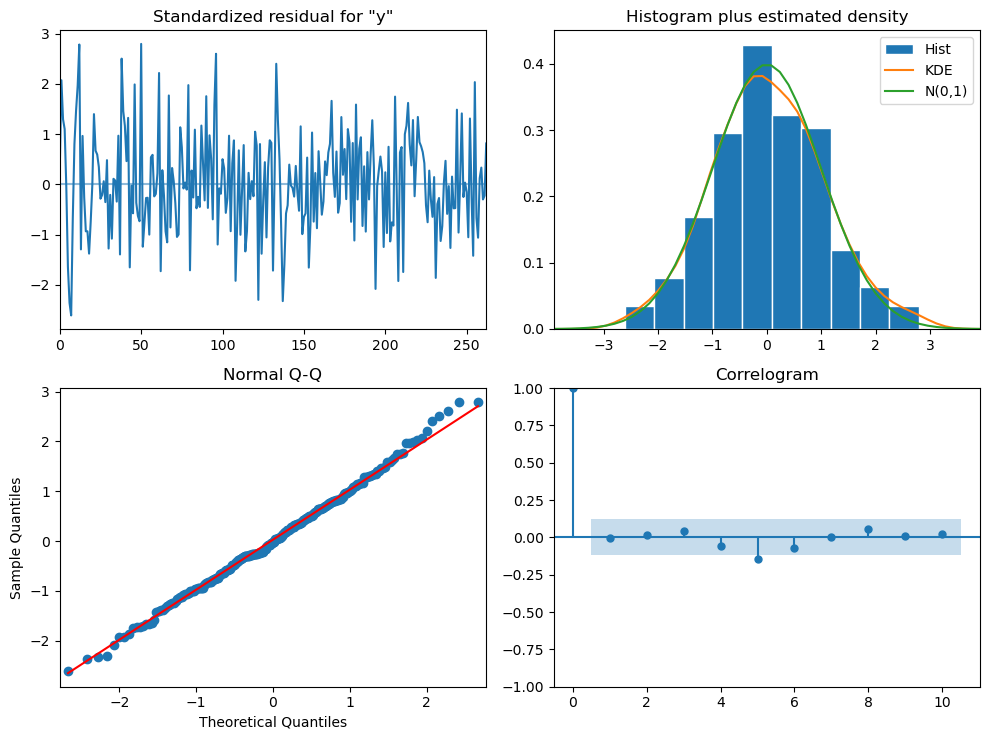

In [64]:
print(acorr_ljungbox(best_model.resid, lags=[1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,24,18,34,36], return_df=True))
best_model.plot_diagnostics(); plt.tight_layout(); plt.show()

In [65]:
best_model.resid

array([ 7.07189375e+00,  1.29357255e-03,  8.18286786e-03,  5.08332815e-03,
        4.31492872e-03, -1.44009166e-04, -6.44385702e-03, -9.24489579e-03,
       -1.02222872e-02, -2.61029289e-03,  3.13119367e-03,  5.72039852e-03,
        7.43536556e-03,  4.48112714e-03, -2.03898795e-03,  1.50990876e-03,
       -4.07440517e-04, -1.46260527e-03, -1.46158679e-03, -2.15725103e-03,
       -1.16204492e-03, -1.21621337e-05,  2.18687574e-03,  1.04650353e-03,
        9.21655866e-04,  4.96834589e-04, -4.10085570e-04, -3.05553699e-04,
        8.83182063e-05, -5.06856472e-04,  6.90080974e-04, -1.83051755e-03,
       -3.00441806e-04, -1.54894436e-03,  1.57929855e-04,  1.10377883e-04,
       -4.90721342e-04,  1.35856245e-03, -1.95610281e-03,  3.50695298e-03,
        2.04486290e-03,  1.62940694e-03,  6.47454449e-04,  1.85404205e-03,
       -2.31585424e-03, -3.75800496e-05, -8.07503400e-04,  2.78662689e-03,
       -5.12390387e-04, -8.76779461e-04, -1.02129269e-03,  3.89178363e-03,
       -1.72755380e-03, -

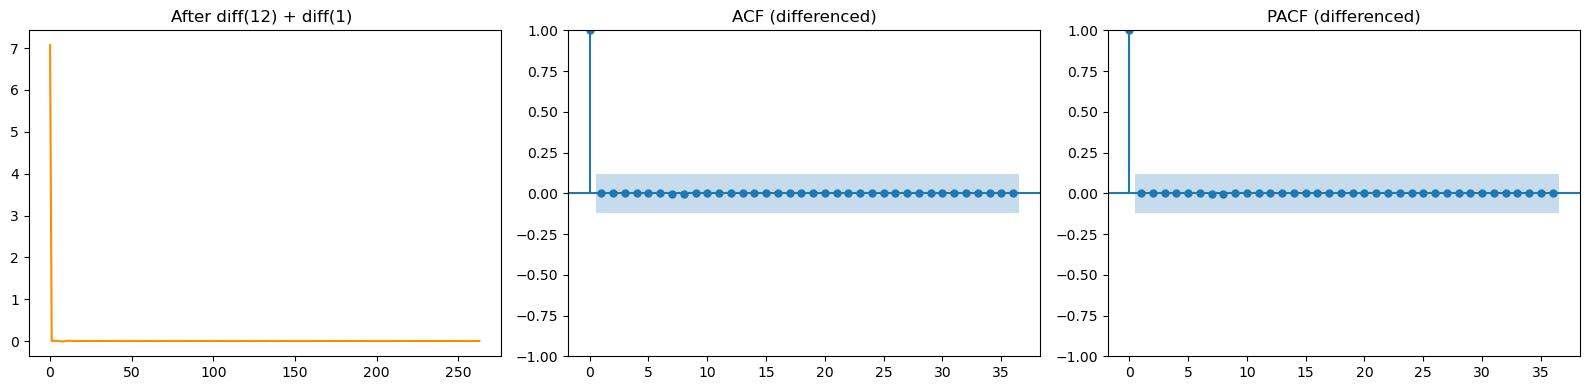

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(best_model.resid, color="darkorange")
axes[0].set_title("After diff(12) + diff(1) ")
plot_acf(best_model.resid,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(best_model.resid, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

In [67]:
best_model.resid

array([ 7.07189375e+00,  1.29357255e-03,  8.18286786e-03,  5.08332815e-03,
        4.31492872e-03, -1.44009166e-04, -6.44385702e-03, -9.24489579e-03,
       -1.02222872e-02, -2.61029289e-03,  3.13119367e-03,  5.72039852e-03,
        7.43536556e-03,  4.48112714e-03, -2.03898795e-03,  1.50990876e-03,
       -4.07440517e-04, -1.46260527e-03, -1.46158679e-03, -2.15725103e-03,
       -1.16204492e-03, -1.21621337e-05,  2.18687574e-03,  1.04650353e-03,
        9.21655866e-04,  4.96834589e-04, -4.10085570e-04, -3.05553699e-04,
        8.83182063e-05, -5.06856472e-04,  6.90080974e-04, -1.83051755e-03,
       -3.00441806e-04, -1.54894436e-03,  1.57929855e-04,  1.10377883e-04,
       -4.90721342e-04,  1.35856245e-03, -1.95610281e-03,  3.50695298e-03,
        2.04486290e-03,  1.62940694e-03,  6.47454449e-04,  1.85404205e-03,
       -2.31585424e-03, -3.75800496e-05, -8.07503400e-04,  2.78662689e-03,
       -5.12390387e-04, -8.76779461e-04, -1.02129269e-03,  3.89178363e-03,
       -1.72755380e-03, -

In [68]:
print("ADF on levels, p =", adfuller(best_model.resid, autolag="AIC")[1])

ADF on levels, p = 0.0


## ¿Mejor Modelo?

In [70]:
co2 = sm.datasets.co2.load_pandas().data['co2']
co2 = co2.resample('MS').mean().interpolate().loc['1980':]

In [71]:
import numpy as np
from scipy import stats

# 1. Prepare your data (Must be strictly positive, > 0)
data = co2

# 2. Apply Box-Cox transformation
# transformed_data: The normalized data
# best_lambda: The automatically chosen optimal lambda value
transformed_data, best_lambda = stats.boxcox(data)

print(f"Optimal Lambda: {best_lambda}")
print(f"Transformed Data: {transformed_data}")

Optimal Lambda: 0.06472191068973673
Transformed Data: [7.07189375 7.07318732 7.08107639 7.08403256 7.08655586 7.08488837
 7.07813609 7.07049117 7.06302548 7.06367609 7.06815793 7.07307956
 7.07747    7.08274796 7.08681224 7.09129205 7.09286759 7.08990682
 7.08264086 7.07394141 7.06660049 7.06763895 7.07404911 7.0791025
 7.08381853 7.087453   7.09225034 7.09565282 7.09771197 7.09490916
 7.08903242 7.07920984 7.07232506 7.0717859  7.07770639 7.08264086
 7.08655586 7.09150505 7.09427146 7.10169518 7.104866   7.1032814
 7.09711786 7.09001342 7.08028285 7.08090485 7.08574372 7.09354841
 7.09650229 7.09968366 7.10285856 7.11223962 7.11202943 7.10912588
 7.10296428 7.09490916 7.08561545 7.08713265 7.09299526 7.0984755
 7.10180098 7.10581599 7.11240775 7.11612308 7.11821824 7.11551496
 7.10824112 7.09915388 7.09363349 7.09278246 7.09881473 7.10454921
 7.10739802 7.1098207  7.11366818 7.12114674 7.12346473 7.12051966
 7.11402511 7.10558382 7.10127192 7.09830586 7.10473929 7.11003119
 7.11475972

In [72]:
# 2. Create matching datetime index (Daily frequency 'MS')
time_index = pd.date_range(start="2026-09-01", periods=len(transformed_data), freq="MS")

# 3. Convert to a Pandas Time Series
time_series = pd.Series(transformed_data, index=time_index)

transformed_data = time_series

print(time_series)

2026-09-01    7.071894
2026-10-01    7.073187
2026-11-01    7.081076
2026-12-01    7.084033
2027-01-01    7.086556
                ...   
2048-04-01    7.202185
2048-05-01    7.196042
2048-06-01    7.196719
2048-07-01    7.201987
2048-08-01    7.208503
Freq: MS, Length: 264, dtype: float64


In [73]:
time_series= time_series.diff(12).diff().dropna()

In [74]:
print("ADF on levels, p =", adfuller(time_series, autolag="AIC")[1])

ADF on levels, p = 4.723437883514974e-08


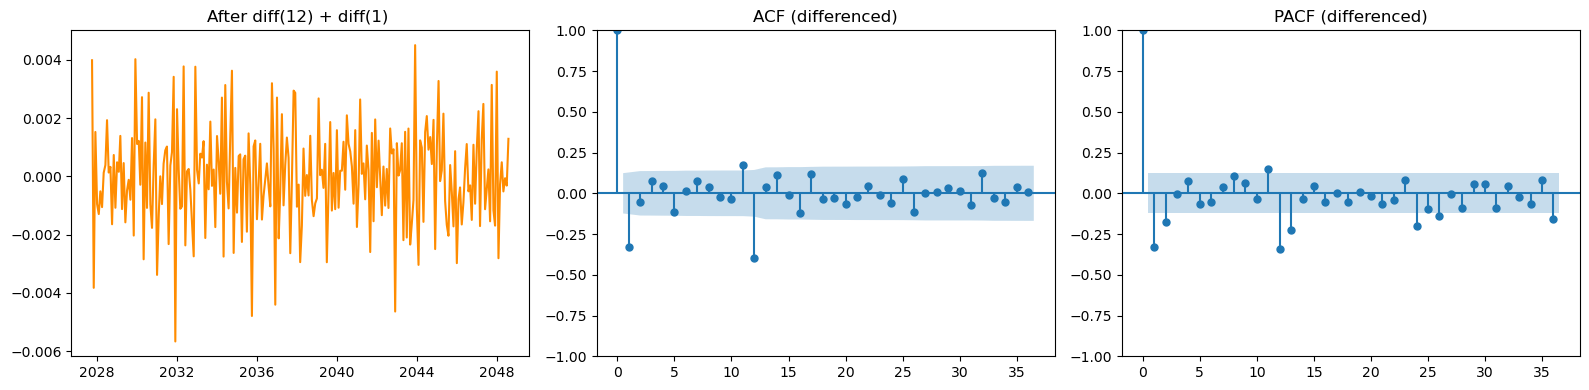

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(time_series, color="darkorange")
axes[0].set_title("After diff(12) + diff(1) ")
plot_acf(time_series,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(time_series, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

In [77]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    transformed_data,
    seasonal=True, m=12,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='aic', # Or 'bic',
    start_p=0, start_q=0,
    max_p=2, max_q=2, d=1, D=0, max_P=2, max_Q=2
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-2654.886, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-2018.388, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-2314.153, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-2017.751, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=-2239.917, Time=0.26 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=-2654.781, Time=0.56 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=-2631.632, Time=0.99 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=-2342.502, Time=0.89 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=-2620.080, Time=1.01 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=-2514.286, Time=0.47 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-2093.772, Time=0.33 sec
 ARIMA(1,1,1)(1,0,1)[12

In [78]:
best_model = ARIMA(transformed_data, order=(1, 1, 1),
                seasonal_order=(1, 0, 1, 12)).fit()
print(best_model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                  264
Model:             ARIMA(1, 1, 1)x(1, 0, 1, 12)   Log Likelihood                1342.242
Date:                          Mon, 14 Sep 2026   AIC                          -2674.484
Time:                                  17:56:17   BIC                          -2656.623
Sample:                              09-01-2026   HQIC                         -2667.306
                                   - 08-01-2048                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2268      0.234      0.970      0.332      -0.232       0.685
ma.L1         -0.4861      0.212     -2.293      0.

El modelo es:
$$ (1-0.9866B^{12})(1-0.2268B)(1-B)x_t=(1-0.5562B^{12})(1-0.4861B)w_t$$
$$ Var[w_t]=1.925e-06$$

     lb_stat  lb_pvalue
1   0.000007   0.997816
2   0.000348   0.999826
3   0.000470   0.999997
4   0.000552   1.000000
5   0.000554   1.000000
6   0.000828   1.000000
7   0.001376   1.000000
8   0.002053   1.000000
9   0.002125   1.000000
10  0.002148   1.000000
11  0.002263   1.000000
12  0.002476   1.000000
13  0.002531   1.000000
14  0.002599   1.000000
15  0.002599   1.000000
24  0.002958   1.000000
18  0.002746   1.000000
34  0.003710   1.000000
36  0.003898   1.000000


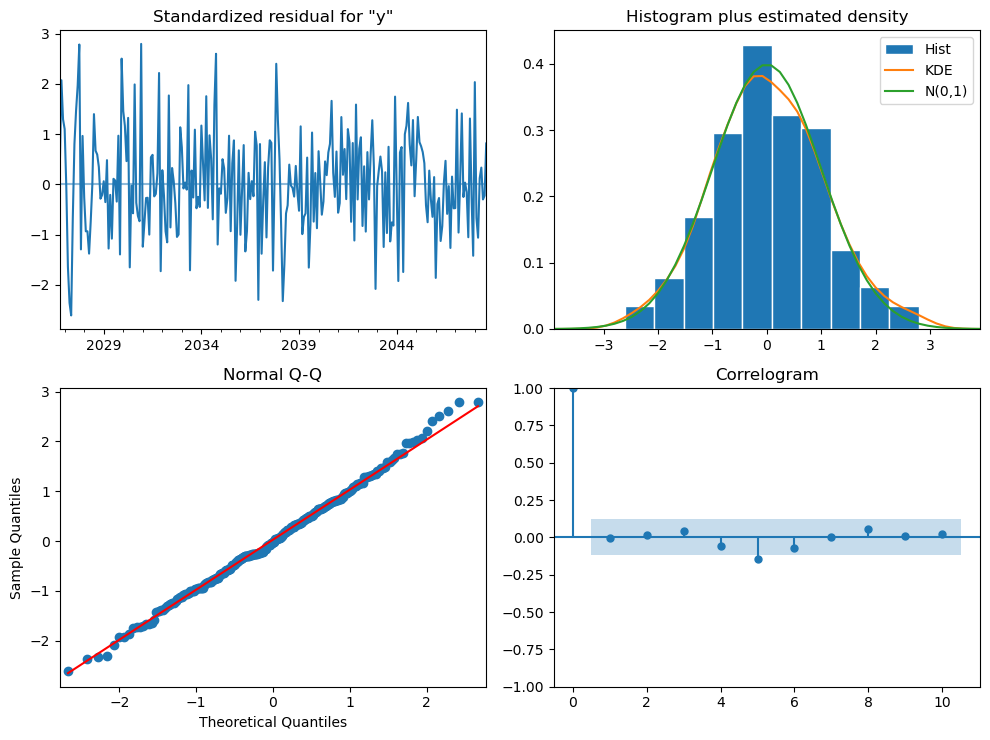

In [79]:
print(acorr_ljungbox(best_model.resid, lags=[1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,24,18,34,36], return_df=True))
best_model.plot_diagnostics(); plt.tight_layout(); plt.show()

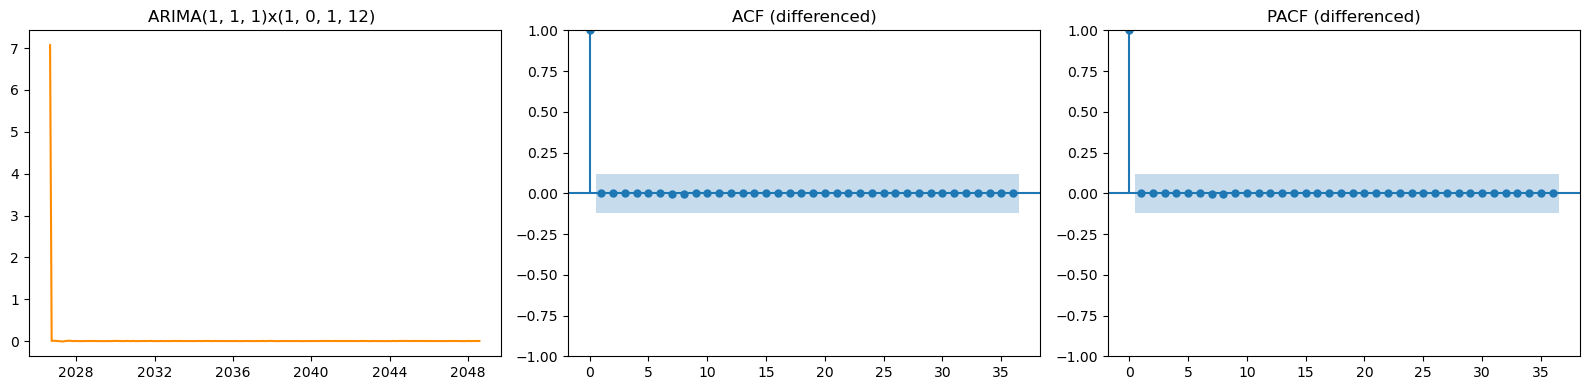

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(best_model.resid, color="darkorange")
axes[0].set_title("ARIMA(1, 1, 1)x(1, 0, 1, 12) ")
plot_acf(best_model.resid,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(best_model.resid, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

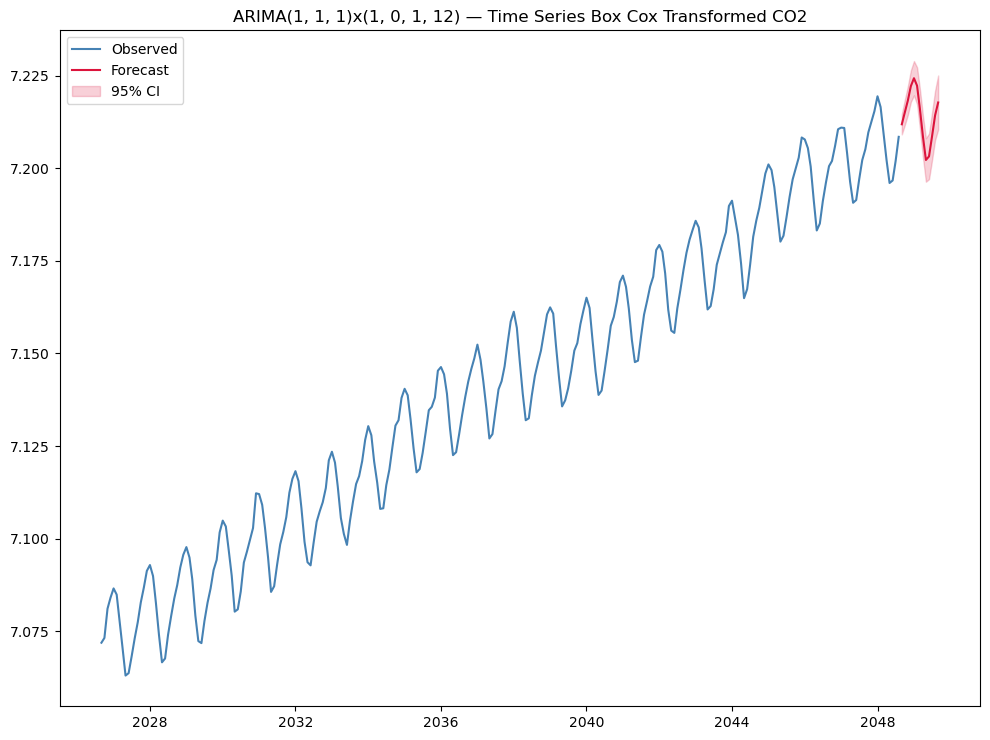

In [81]:
# 5. Forecast 13 periods 
# ---------------------------------------------------------------
steps = 13
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(transformed_data.index[-1], periods=steps + 1, freq="MS")[1:]

fig, ax = plt.subplots()
ax.plot(transformed_data, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(1, 1, 1)x(1, 0, 1, 12) — Time Series Box Cox Transformed CO2")
ax.legend(); plt.tight_layout(); plt.show()

## Simula ARMA(2,2)

In [120]:
norm_callable = lambda size: rng.normal(size=size)

rng = np.random.default_rng(seed=42)
ar2 = np.array([1, 0.33, 0.5])
ma2 = np.array([1, 0.9, 0.3])

In [121]:
ARMA_22 = ArmaProcess(ar2, ma2).generate_sample(nsample=1000, distrvs=norm_callable)
##ArmaProcess(ar2, ma2).generate_sample

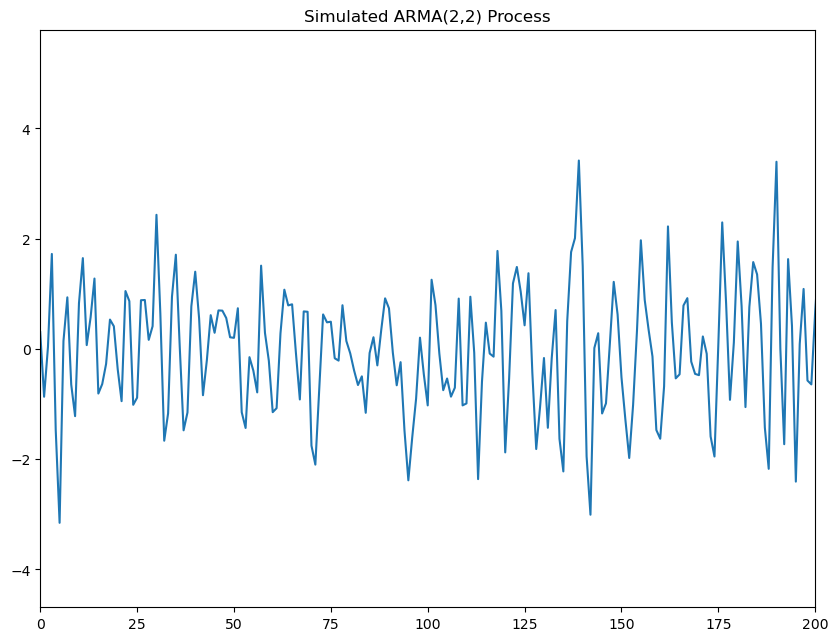

In [122]:
plt.plot(ARMA_22)
plt.title("Simulated ARMA(2,2) Process")
plt.xlim([0, 200])
plt.show()

In [123]:
# 2. Create matching datetime index (Daily frequency 'D')
time_index = pd.date_range(start="2026-09-01", periods=len(ARMA_22), freq="D")

# 3. Convert to a Pandas Time Series
time_series = pd.Series(ARMA_22, index=time_index)

print(time_series)

2026-09-01    0.304717
2026-09-02   -0.866295
2026-09-03    0.039400
2026-09-04    1.724121
2026-09-05   -1.468051
                ...   
2029-05-23   -0.035333
2029-05-24    1.099068
2029-05-25    0.572108
2029-05-26   -0.268459
2029-05-27    0.780331
Freq: D, Length: 1000, dtype: float64


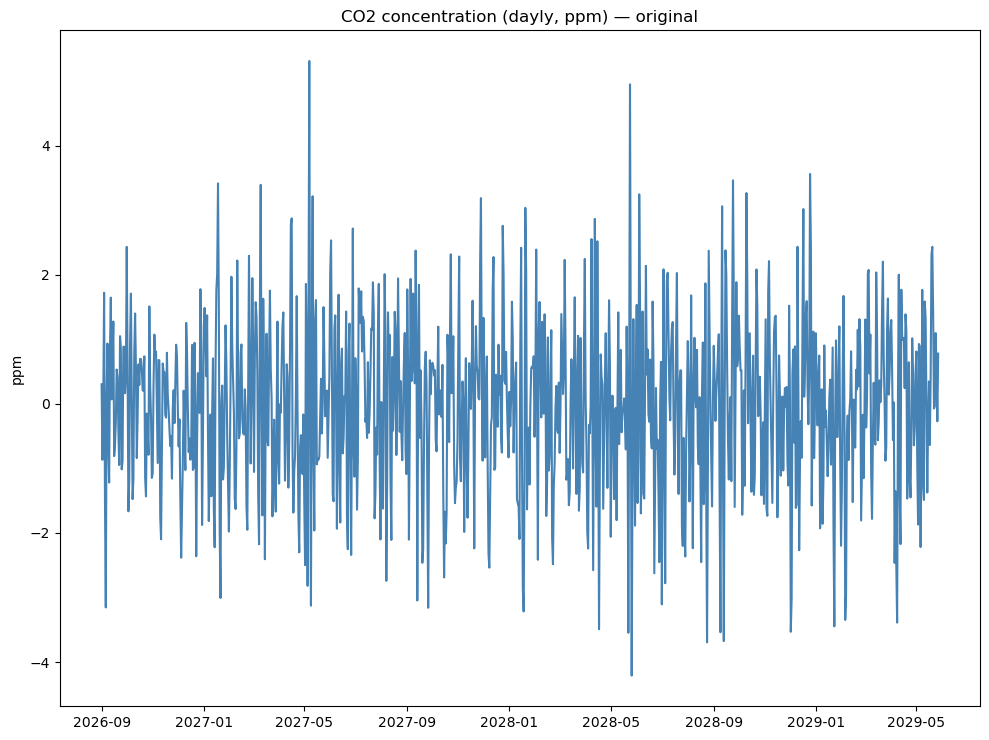

In [124]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(time_series, color="steelblue")
ax.set_title("CO2 concentration (dayly, ppm) — original")
ax.set_ylabel("ppm")
plt.tight_layout(); plt.show()

In [125]:
print("ADF on levels, p =", adfuller(time_series, autolag="AIC")[1])

ADF on levels, p = 2.1522350650993697e-26


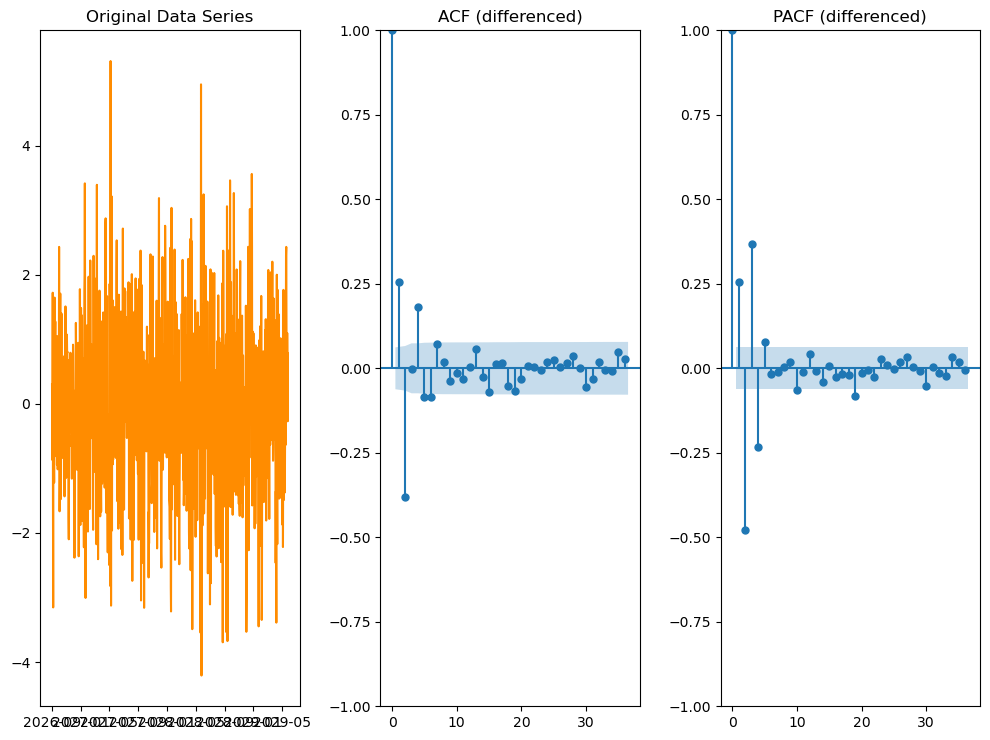

In [126]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(time_series, color="darkorange")
axes[0].set_title("Original Data Series")
plot_acf(time_series,  ax=axes[1], lags=36, title="ACF (differenced)")
plot_pacf(time_series, ax=axes[2], lags=36, title="PACF (differenced)", method="ywm")
plt.tight_layout(); plt.show()

In [129]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    time_series,
    seasonal=False, m=12,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='aic', # Or 'bic',
    start_p=0, start_q=0,
    max_p=2, max_q=2
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3343.932, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=3277.595, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2977.211, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2964.746, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2834.508, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=3020.043, Time=0.04 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2817.753, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2918.433, Time=0.13 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=2818.977, Time=0.33 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0]          
Total fit time: 0.860 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -1403.876
Date:                Mon, 14 Sep 2026   AIC      

In [128]:
from statsmodels.tsa.arima.model import ARIMA
ARMA_model = ARIMA(time_series, order=(2,0,2), enforce_stationarity=False).fit()

print(ARMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1399.646
Date:                Mon, 14 Sep 2026   AIC                           2811.292
Time:                        18:11:59   BIC                           2840.720
Sample:                    09-01-2026   HQIC                          2822.478
                         - 05-27-2029                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0336      0.040     -0.850      0.395      -0.111       0.044
ar.L1         -0.2949      0.068     -4.348      0.000      -0.428      -0.162
ar.L2         -0.4989      0.033    -14.956      0.0

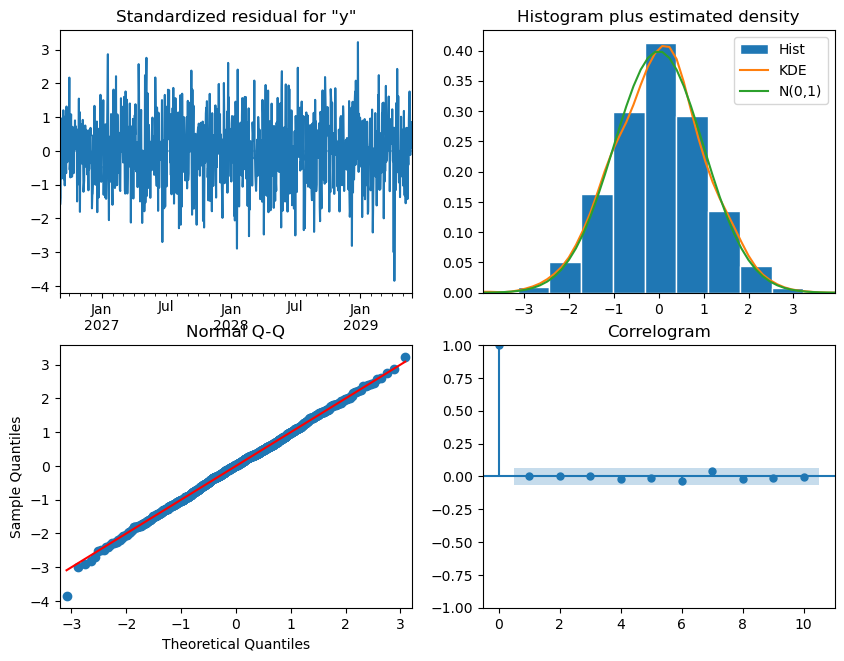

In [130]:
ARMA_model.plot_diagnostics()
plt.show()

In [131]:
print(acorr_ljungbox(best_model.resid, lags=[1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,24,18,34,36], return_df=True))

     lb_stat  lb_pvalue
1   0.000007   0.997816
2   0.000348   0.999826
3   0.000470   0.999997
4   0.000552   1.000000
5   0.000554   1.000000
6   0.000828   1.000000
7   0.001376   1.000000
8   0.002053   1.000000
9   0.002125   1.000000
10  0.002148   1.000000
11  0.002263   1.000000
12  0.002476   1.000000
13  0.002531   1.000000
14  0.002599   1.000000
15  0.002599   1.000000
24  0.002958   1.000000
18  0.002746   1.000000
34  0.003710   1.000000
36  0.003898   1.000000


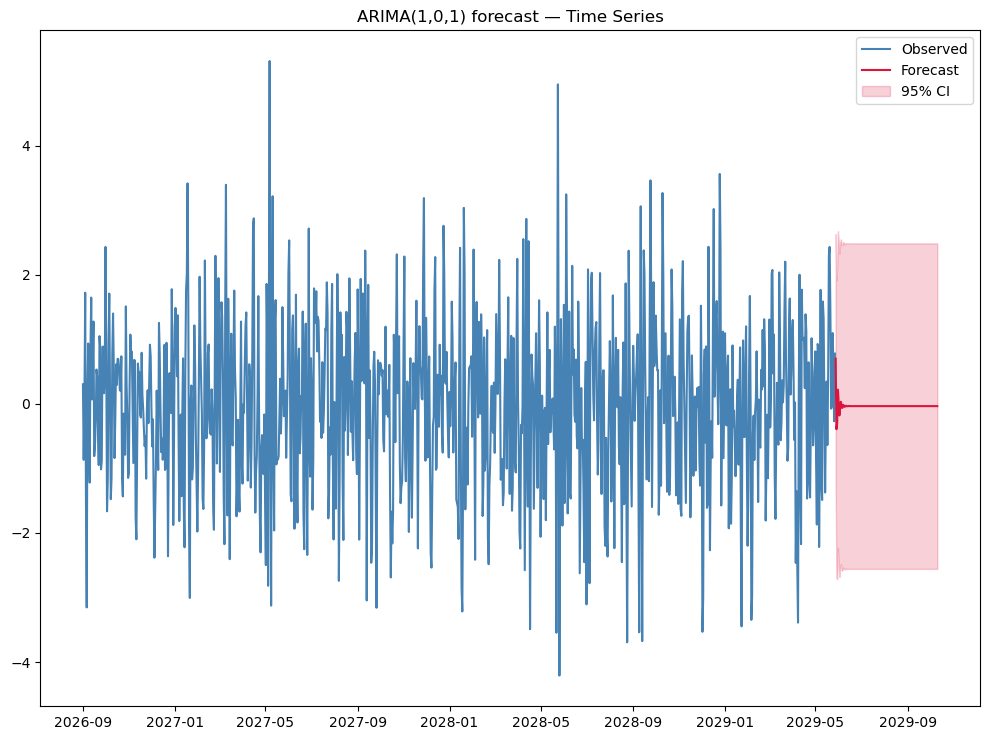

In [132]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 136
fc   = ARMA_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(time_series.index[-1], periods=steps + 1, freq="D")[1:]

fig, ax = plt.subplots()
ax.plot(time_series, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(1,0,1) forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

In [133]:
from statsmodels.tsa.arima.model import ARIMA
ARMA_model = ARIMA(time_series, order=(2,0,2), enforce_stationarity=False).fit()

print(ARMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1399.646
Date:                Mon, 14 Sep 2026   AIC                           2811.292
Time:                        18:19:23   BIC                           2840.720
Sample:                    09-01-2026   HQIC                          2822.478
                         - 05-27-2029                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0336      0.040     -0.850      0.395      -0.111       0.044
ar.L1         -0.2949      0.068     -4.348      0.000      -0.428      -0.162
ar.L2         -0.4989      0.033    -14.956      0.0

In [134]:
time_series.values.mean()

np.float64(-0.03501404344849594)

El modelo ajustado es : 
$$ y_t -\mu -  \phi_1 (y_{t-1}-\mu) -  \phi_2 (y_{t-2}-\mu)=w_t+\theta_1w_{t-1} +\theta_2w_{t-2}$$

Con $\phi_1 = -0.2949$, $\phi_2 = -0.4989$, $\theta_1=0.9506$, $\theta_2=0.3146$. $Var(w_t)=0.9693$. $E[y_t]=-0.0336$

## Ejemplo JJ

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = [10, 7.5]

%matplotlib inline

In [2]:
jj = pd.read_csv('jj.csv')
jj

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02


In [3]:
#jj = pd.read_csv('jj.csv')

time_series = pd.read_csv('jj.csv', parse_dates=['data'], index_col='date')

In [4]:
time_series

,data
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61
...,...
1979-10-01,9.99
1980-01-01,16.2
1980-04-01,14.67


In [5]:
jj['data']

0      0.71
1      0.63
2      0.85
3      0.44
4      0.61
      ...  
79     9.99
80    16.20
81    14.67
82    16.02
83    11.61
Name: data, Length: 84, dtype: float64

In [6]:
jj['data']

0      0.71
1      0.63
2      0.85
3      0.44
4      0.61
      ...  
79     9.99
80    16.20
81    14.67
82    16.02
83    11.61
Name: data, Length: 84, dtype: float64

In [7]:
# 2. Create matching datetime index (Daily frequency 'D')
time_index = pd.date_range(start="1960-01-01", periods=time_series.shape[0], freq="Q")

# 3. Convert to a Pandas Time Series
time_series = pd.Series(jj['data'].values, index=time_index)

print(time_series)
print(time_index)

1960-03-31     0.71
1960-06-30     0.63
1960-09-30     0.85
1960-12-31     0.44
1961-03-31     0.61
              ...  
1979-12-31     9.99
1980-03-31    16.20
1980-06-30    14.67
1980-09-30    16.02
1980-12-31    11.61
Freq: QE-DEC, Length: 84, dtype: float64
DatetimeIndex(['1960-03-31', '1960-06-30', '1960-09-30', '1960-12-31',
               '1961-03-31', '1961-06-30', '1961-09-30', '1961-12-31',
               '1962-03-31', '1962-06-30', '1962-09-30', '1962-12-31',
               '1963-03-31', '1963-06-30', '1963-09-30', '1963-12-31',
               '1964-03-31', '1964-06-30', '1964-09-30', '1964-12-31',
               '1965-03-31', '1965-06-30', '1965-09-30', '1965-12-31',
               '1966-03-31', '1966-06-30', '1966-09-30', '1966-12-31',
               '1967-03-31', '1967-06-30', '1967-09-30', '1967-12-31',
               '1968-03-31', '1968-06-30', '1968-09-30', '1968-12-31',
               '1969-03-31', '1969-06-30', '1969-09-30', '1969-12-31',
               '1970-03-31', 

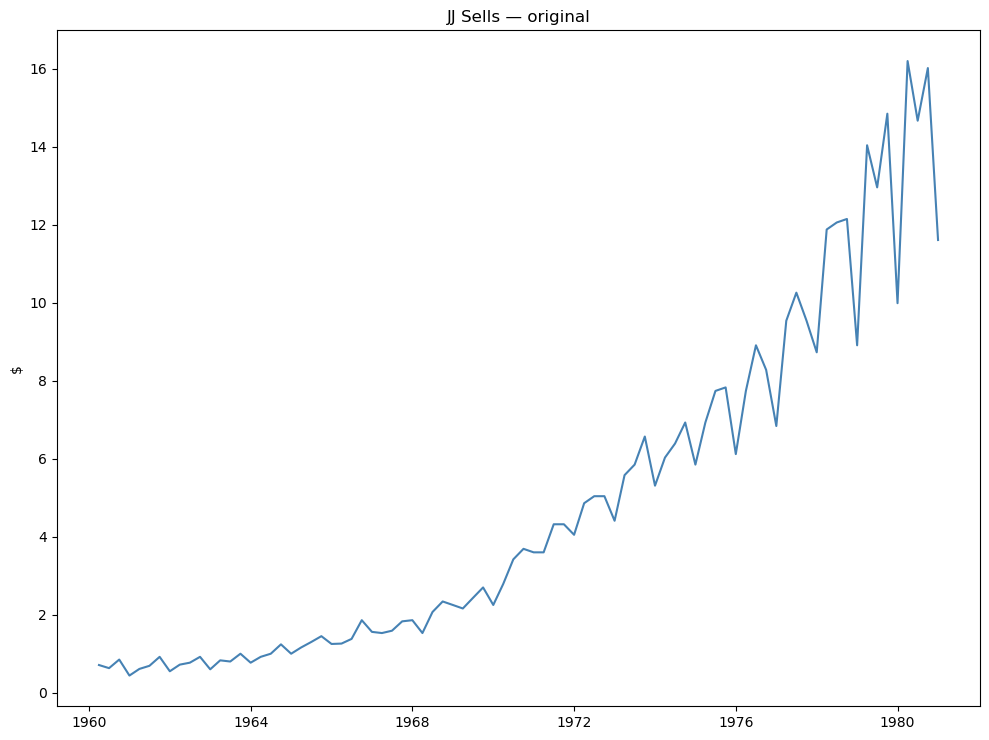

In [8]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(time_series, color="steelblue")
ax.set_title("JJ Sells — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

In [9]:
jj_diff = time_series.diff(4).dropna()

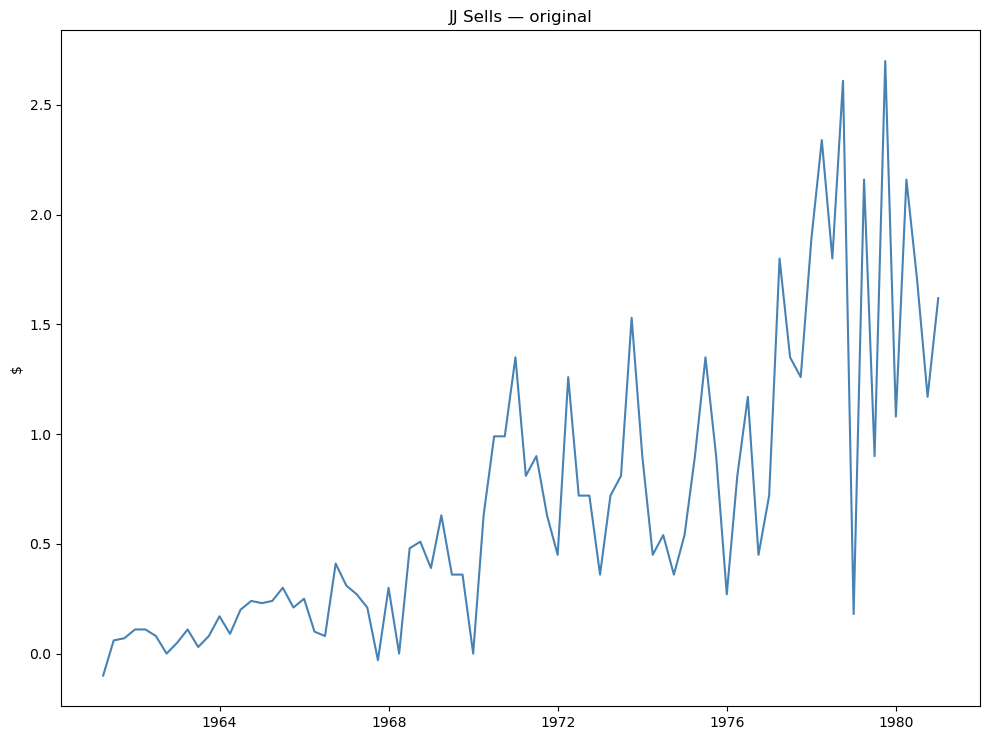

In [10]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(jj_diff, color="steelblue")
ax.set_title("JJ Sells — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

In [11]:
print("ADF on levels, p =", adfuller(jj_diff, autolag="AIC")[1])

ADF on levels, p = 0.9191818417006344


In [12]:
jj_diff = time_series.diff(4).diff().dropna()

In [13]:
print("ADF on levels, p =", adfuller(jj_diff, autolag="AIC")[1])

ADF on levels, p = 1.0769336844683958e-08


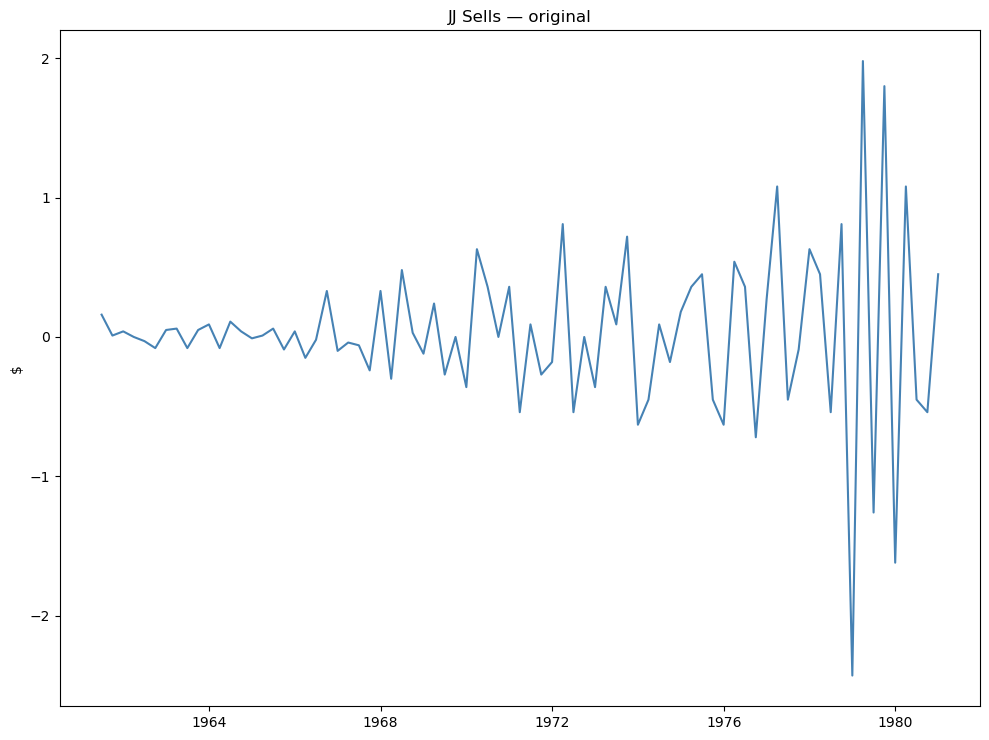

In [14]:
# Create the plot
fig, ax = plt.subplots()
ax.plot(jj_diff, color="steelblue")
ax.set_title("JJ Sells — original")
ax.set_ylabel("$")
plt.tight_layout(); plt.show()

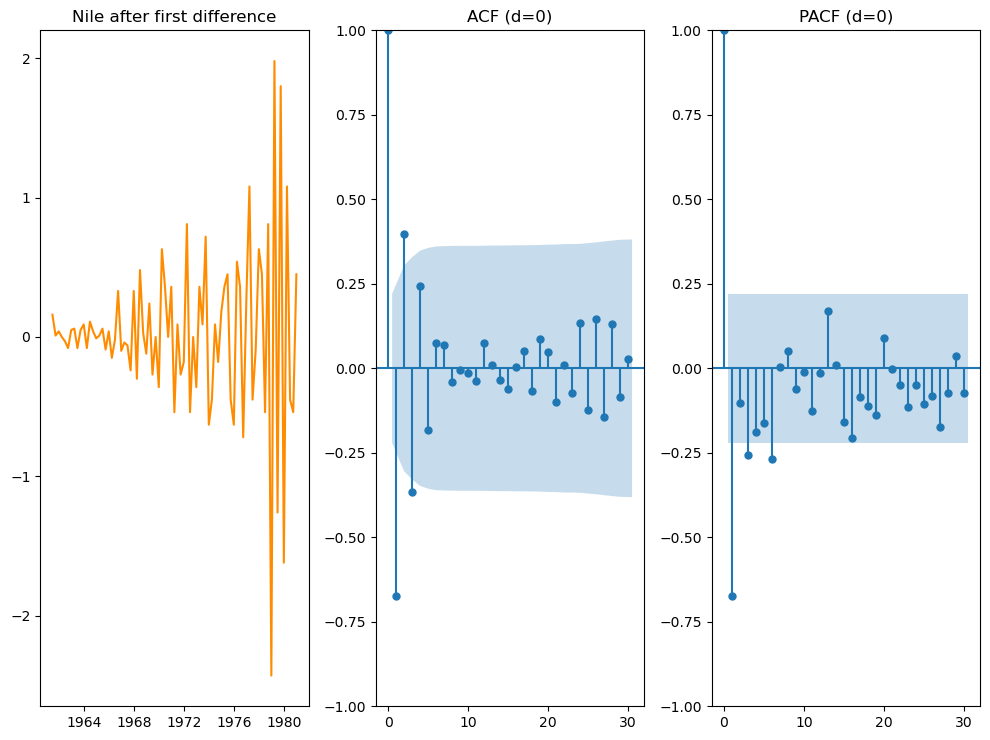

In [15]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(jj_diff, color="darkorange")
axes[0].set_title("Nile after first difference")
plot_acf(jj_diff,  ax=axes[1], lags=30, title="ACF (d=0)")
plot_pacf(jj_diff, ax=axes[2], lags=30, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [16]:
import pmdarima as pm

# 'y' is your time series data
# Set 'seasonal=True' and 'm' to your seasonal period (e.g., 12 for monthly)
auto_model = pm.auto_arima(
    time_series,
    seasonal=True, m=4,
    test='adf',              # Use ADF test for stationarity
    stepwise=True,           # Use stepwise search to save time
    trace=True,              # Print the search progress
    information_criterion='aic', # Or 'bic',
    start_p=0, start_q=0, start_P=0,start_Q=0,
    max_p=2, max_q=2, d=1, D=1, max_P=0, max_Q=0
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[4]             : AIC=145.581, Time=0.03 sec
 ARIMA(1,1,0)(0,1,0)[4]             : AIC=100.207, Time=0.05 sec
 ARIMA(0,1,1)(0,1,0)[4]             : AIC=100.126, Time=0.04 sec
 ARIMA(1,1,1)(0,1,0)[4]             : AIC=98.208, Time=0.05 sec
 ARIMA(2,1,1)(0,1,0)[4]             : AIC=96.634, Time=0.08 sec
 ARIMA(2,1,0)(0,1,0)[4]             : AIC=101.521, Time=0.04 sec
 ARIMA(2,1,2)(0,1,0)[4]             : AIC=97.032, Time=0.07 sec
 ARIMA(1,1,2)(0,1,0)[4]             : AIC=96.135, Time=0.07 sec
 ARIMA(0,1,2)(0,1,0)[4]             : AIC=99.731, Time=0.04 sec
 ARIMA(1,1,2)(0,1,0)[4] intercept   : AIC=94.868, Time=0.21 sec
 ARIMA(0,1,2)(0,1,0)[4] intercept   : AIC=98.342, Time=0.07 sec
 ARIMA(1,1,1)(0,1,0)[4] intercept   : AIC=97.497, Time=0.08 sec
 ARIMA(2,1,2)(0,1,0)[4] intercept   : AIC=92.455, Time=0.22 sec
 ARIMA(2,1,1)(0,1,0)[4] intercept   : AIC=inf, Time=0.19 sec

Best model:  ARIMA(2,1,2)(0,1,0)[4] intercept
Total fit tim

In [17]:
best_model = ARIMA(time_series, order=(2, 1, 2),
                seasonal_order=(0, 1, 0, 4)).fit()
print(best_model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                   84
Model:             ARIMA(2, 1, 2)x(0, 1, [], 4)   Log Likelihood                 -43.516
Date:                          Tue, 15 Sep 2026   AIC                             97.032
Time:                                  14:29:40   BIC                            108.879
Sample:                              03-31-1960   HQIC                           101.779
                                   - 12-31-1980                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4764      0.450     -1.059      0.290      -1.359       0.406
ar.L2          0.2082      0.256      0.814      0.

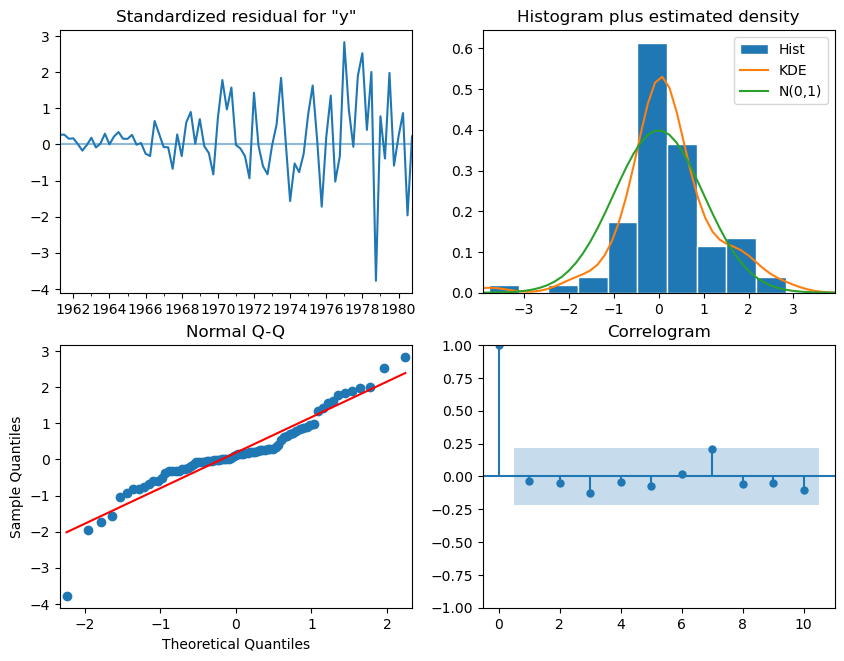

In [18]:
best_model.plot_diagnostics()
plt.show()

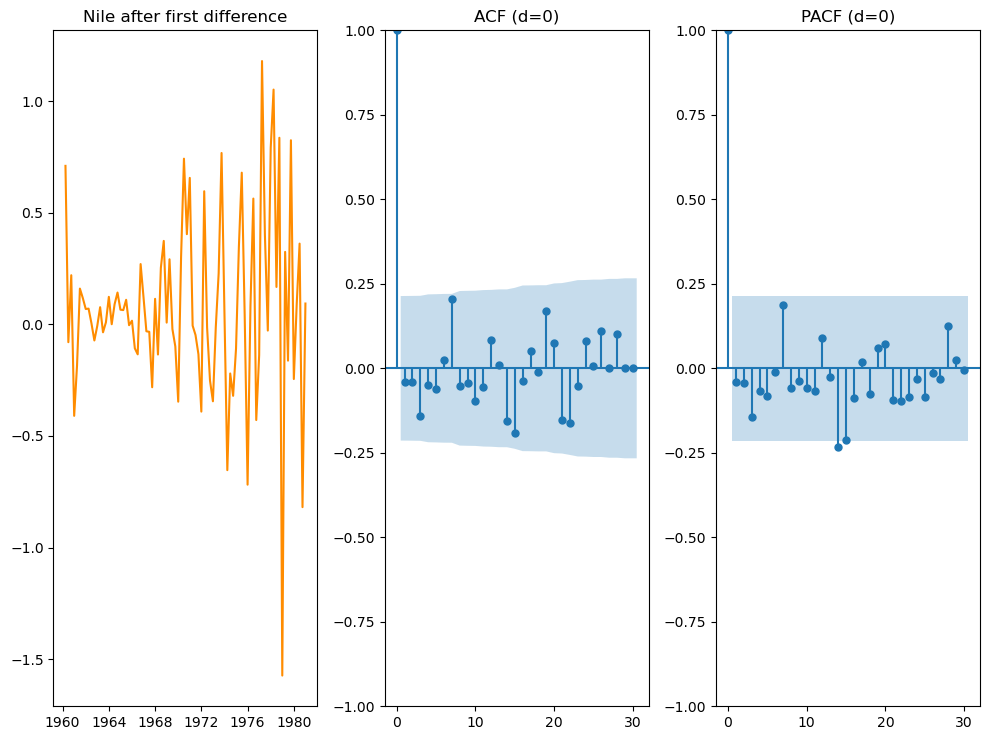

In [19]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(best_model.resid, color="darkorange")
axes[0].set_title("Nile after first difference")
plot_acf(best_model.resid,  ax=axes[1], lags=30, title="ACF (d=0)")
plot_pacf(best_model.resid, ax=axes[2], lags=30, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

In [20]:
best_model.resid

1960-03-31    0.710000
1960-06-30   -0.080000
1960-09-30    0.220000
1960-12-31   -0.410000
1961-03-31   -0.185000
                ...   
1979-12-31   -0.245092
1980-03-31    0.090243
1980-06-30    0.361675
1980-09-30   -0.819066
1980-12-31    0.093200
Freq: QE-DEC, Length: 84, dtype: float64

In [21]:
print(acorr_ljungbox(best_model.resid, lags=[1, 2,3,4,5,6,7,8,9,10], return_df=True))

     lb_stat  lb_pvalue
1   0.139891   0.708389
2   0.289432   0.865268
3   2.059963   0.560055
4   2.288905   0.682790
5   2.639172   0.755405
6   2.696872   0.845817
7   6.605594   0.471066
8   6.880876   0.549538
9   7.068305   0.630008
10  7.964760   0.632279


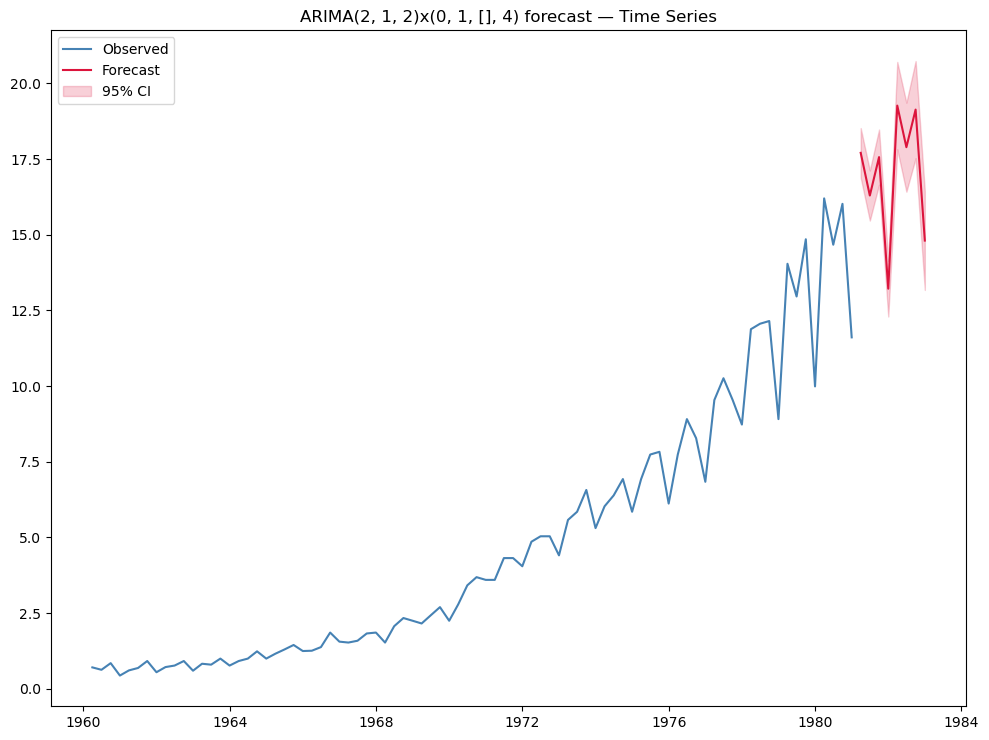

In [22]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(time_series.index[-1], periods=steps + 1, freq="Q")[1:]

fig, ax = plt.subplots()
ax.plot(time_series, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 1, 2)x(0, 1, [], 4) forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

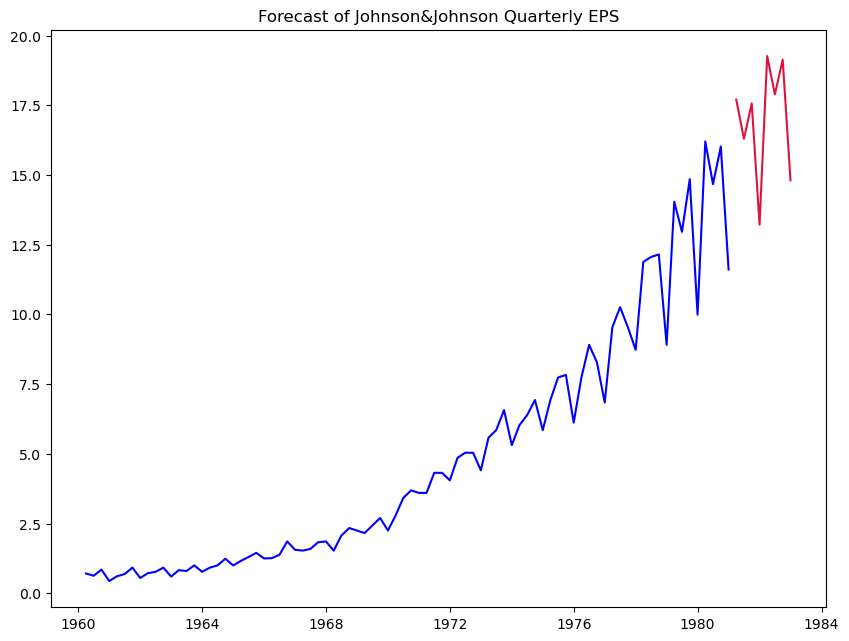

In [27]:
n_forecast = steps
predict = best_model.get_prediction(end=best_model.nobs + n_forecast)
future_idx = pd.date_range(time_series.index[-1], periods=steps + 1, freq="Q")[1:]

fig, ax = plt.subplots()
ax.plot(time_series, 'blue')
##ax.plot(idx[-n_forecast:], predict.predicted_mean[-n_forecast:], 'k--')
ax.plot(future_idx, mean, label="Forecast", color="crimson")

ax.set(title='Forecast of Johnson&Johnson Quarterly EPS')
plt.show()

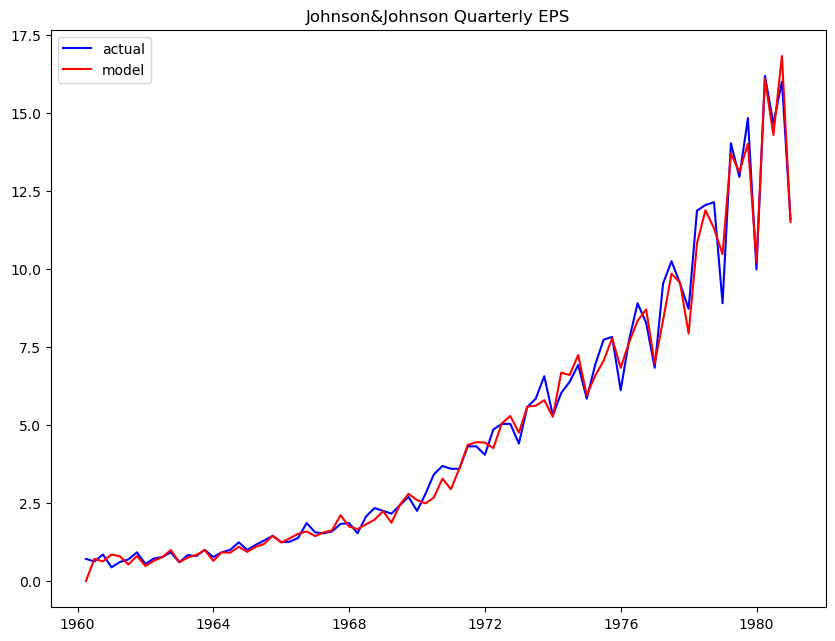

In [38]:
predicted=best_model.predict()
plt.plot(time_series, color='blue', label='actual')
plt.plot(predicted, color='red', label='model')
plt.legend(loc='best')
plt.title('Johnson&Johnson Quarterly EPS')
plt.show()

In [41]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook
import numpy as np
import pandas as pd

from itertools import product

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
def optimize_SARIMA(endog, parameters_list, d, D, s):
    """
        Return dataframe with parameters, corresponding AIC and SSE
        
        parameters_list - list with (p, q, P, Q) tuples
        d - integration order
        D - seasonal integration order
        s - length of season
        endog - the observed variable
    """
    
    results = []
    
    for param in tqdm_notebook(parameters_list):
        try: 
            model = SARIMAX(endog, order=(param[0], d, param[1]), seasonal_order=(param[2], D, param[3], s), simple_differencing=False).fit(disp=False)
        except:
            continue
            
        aic = model.aic
        results.append([param, aic])
        
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)x(P,Q)', 'AIC']
    
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    
    return result_df

In [42]:
p = range(0, 4, 1)
d = 1
q = range(0, 4, 1)
P = range(0, 4, 1)
D = 1
Q = range(0, 4, 1)
s = 4

parameters = product(p, q, P, Q)
parameters_list = list(parameters)

print(len(parameters_list))
print(parameters_list[:5])

256
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 0, 2), (0, 0, 0, 3), (0, 0, 1, 0)]


In [43]:
result_df = optimize_SARIMA(time_series, parameters_list, 1, 1, 4)
result_df

  0%|          | 0/256 [00:00<?, ?it/s]

,"(p,q)x(P,Q)",AIC
0,"(2, 3, 0, 0)",92.587105
1,"(2, 3, 1, 0)",93.977087
2,"(2, 3, 0, 1)",94.132525
3,"(3, 3, 0, 0)",94.468422
4,"(3, 2, 1, 2)",95.085750
...,...,...
251,"(0, 0, 3, 1)",144.211576
252,"(0, 0, 3, 3)",145.086445
253,"(0, 0, 2, 3)",145.465207
254,"(0, 0, 3, 2)",145.563923


In [44]:
best_model = ARIMA(time_series, order=(2, 1, 3),
                seasonal_order=(0, 1, 0, 4)).fit()
print(best_model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                   84
Model:             ARIMA(2, 1, 3)x(0, 1, [], 4)   Log Likelihood                 -40.294
Date:                          Tue, 15 Sep 2026   AIC                             92.587
Time:                                  15:00:51   BIC                            106.804
Sample:                              03-31-1960   HQIC                            98.283
                                   - 12-31-1980                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4848      0.116    -12.801      0.000      -1.712      -1.257
ar.L2         -0.7907      0.131     -6.024      0.

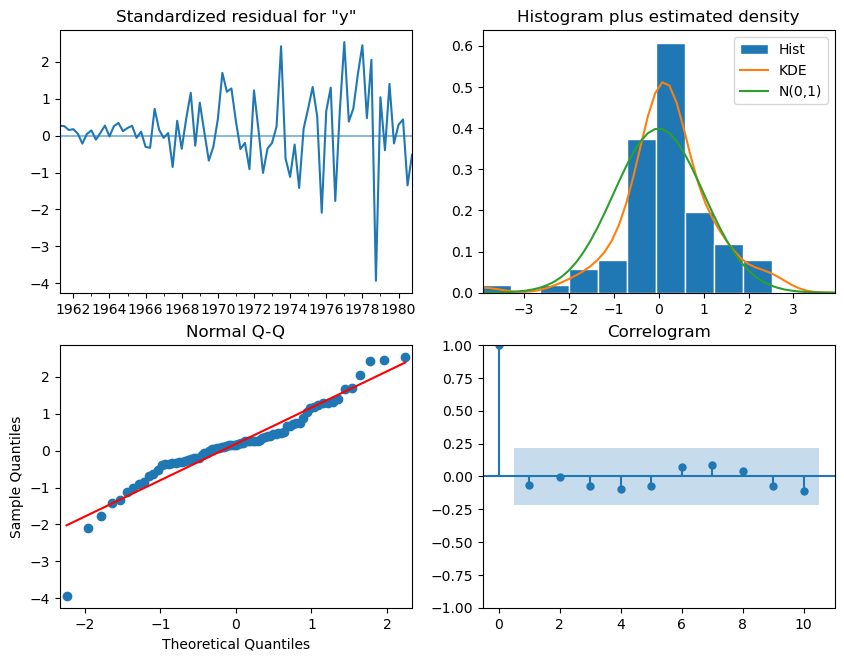

In [45]:
best_model.plot_diagnostics()
plt.show()

In [46]:
print(acorr_ljungbox(best_model.resid, lags=[1, 2,3,4,5,6,7,8,9,10], return_df=True)) #para validar debe  ser mayor que 0.05

     lb_stat  lb_pvalue
1   0.392197   0.531147
2   0.392622   0.821757
3   1.061564   0.786360
4   2.102982   0.716825
5   2.471292   0.780812
6   3.009703   0.807628
7   3.777594   0.805008
8   3.939753   0.862518
9   4.354825   0.886547
10  5.448265   0.859296


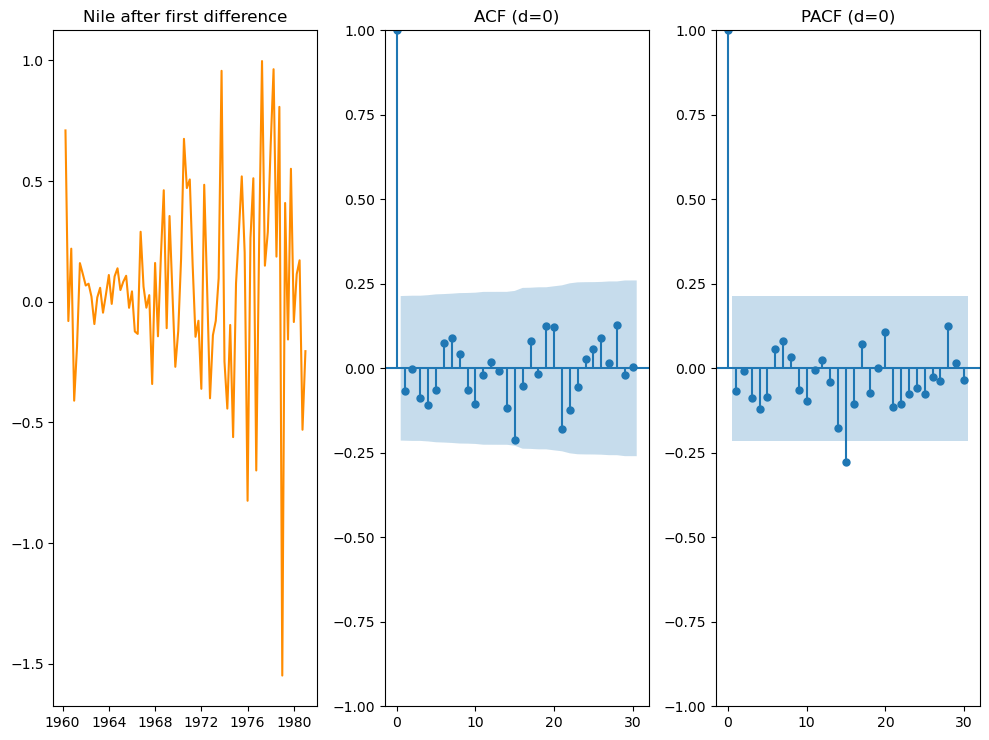

In [47]:
fig, axes = plt.subplots(1, 3)
axes[0].plot(best_model.resid, color="darkorange")
axes[0].set_title("Nile after first difference")
plot_acf(best_model.resid,  ax=axes[1], lags=30, title="ACF (d=0)")
plot_pacf(best_model.resid, ax=axes[2], lags=30, title="PACF (d=0)", method="ywm")
plt.tight_layout(); plt.show()

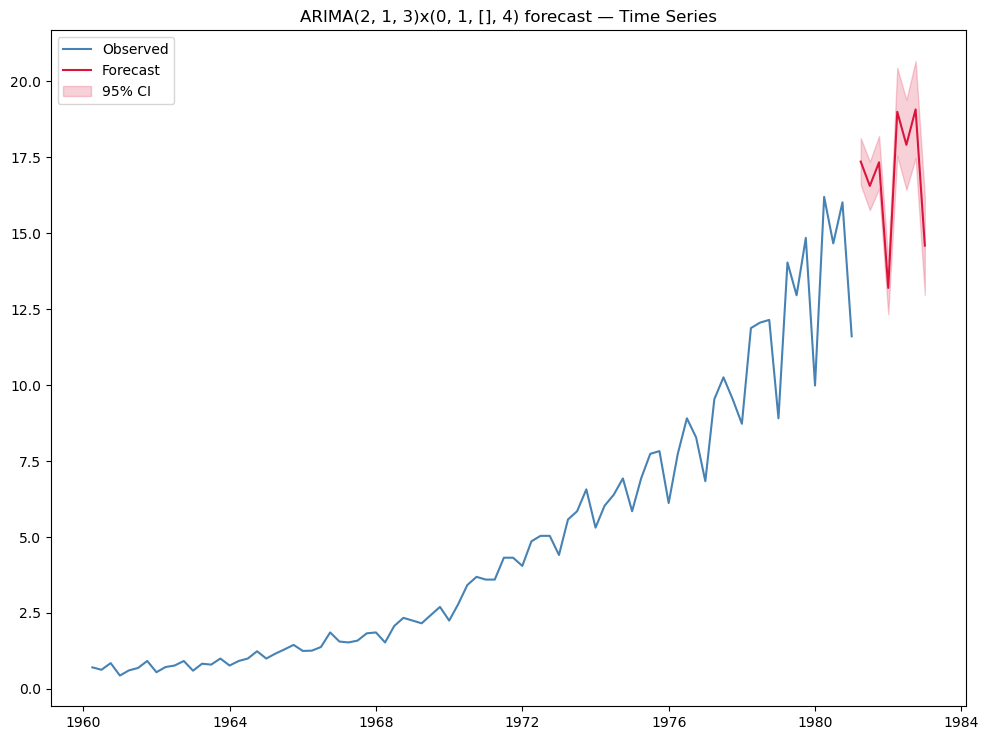

In [48]:
# 5. Forecast 136 periods 
# ---------------------------------------------------------------
steps = 8
fc   = best_model.get_forecast(steps=steps)
mean = fc.predicted_mean
ci   = fc.conf_int(alpha=0.05)

future_idx = pd.date_range(time_series.index[-1], periods=steps + 1, freq="Q")[1:]

fig, ax = plt.subplots()
ax.plot(time_series, label="Observed", color="steelblue")
ax.plot(future_idx, mean, label="Forecast", color="crimson")
ax.fill_between(future_idx, ci.iloc[:, 0], ci.iloc[:, 1],
                color="crimson", alpha=0.2, label="95% CI")
ax.set_title("ARIMA(2, 1, 3)x(0, 1, [], 4) forecast — Time Series")
ax.legend(); plt.tight_layout(); plt.show()

In [49]:
best_model = ARIMA(time_series, order=(2, 1, 3),
                seasonal_order=(0, 1, 0, 4)).fit()
print(best_model .summary())

                                    SARIMAX Results                                     
Dep. Variable:                                y   No. Observations:                   84
Model:             ARIMA(2, 1, 3)x(0, 1, [], 4)   Log Likelihood                 -40.294
Date:                          Tue, 15 Sep 2026   AIC                             92.587
Time:                                  15:24:14   BIC                            106.804
Sample:                              03-31-1960   HQIC                            98.283
                                   - 12-31-1980                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4848      0.116    -12.801      0.000      -1.712      -1.257
ar.L2         -0.7907      0.131     -6.024      0.

El modelo es:
$$ (1+1.4848B+0.7907B^2)(1-B)(1-B^4)x_t=(1+0.7700B-0.1097B^2-0.7335B^3)w_t$$
$$ Var[w_t]=0.1517$$